# 🧠 End-to-End Diagnostic Visualization & Scientific Insights
## Eye Movement-Based Schizophrenia Recognition — 5-Tier Hierarchical Framework

---

Notebook này trực quan hóa **dữ liệu thực tế** từng bước trong pipeline, từ tiền xử lý thô cho đến kết quả Meta-Learner Ensemble cuối cùng, kèm biện luận y sinh và học máy chuyên sâu.

| Phần | Nội dung | Tier tương ứng |
|------|----------|----------------|
| **1** | EDA & Preprocessing Verification | Tier 1 |
| **2** | Feature Engineering Diagnostics | Tier 2 |
| **3** | Tabular Baseline OOF Interpretation | Tier 3 |
| **4** | Deep Model Attention & Embeddings | Tier 4 |
| **5** | Meta-Learner Ensemble & SOTA Comparison | Tier 5 |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition"

Mounted at /content/drive
/content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition


In [4]:
# ── Global Setup ──────────────────────────────────────────────────────────────
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Set2')

PROJECT_ROOT = Path('/content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition')
sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
np.random.seed(SEED)

COLOR_HC   = '#2196F3'
COLOR_SZ   = '#F44336'
COLOR_T3   = '#4CAF50'
COLOR_T4   = '#FF9800'
COLOR_T5   = '#9C27B0'
COLOR_SOTA = '#607D8B'

print('✅ Setup hoàn tất — PROJECT_ROOT:', PROJECT_ROOT)

✅ Setup hoàn tất — PROJECT_ROOT: /content/drive/MyDrive/Eye Movement-Based Schizophrenia Recognition


In [2]:
# ── Cài thư viện cần thiết (nếu chưa có trên Colab) ──────────────────────────
!pip install -q xgboost lightgbm shap pyarrow openpyxl
print('✅ Packages sẵn sàng.')

✅ Packages sẵn sàng.


In [ ]:
# ── Global Setup ──────────────────────────────────────────────────────────────
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('Set2')

# Project root (adjust if notebook is moved)
PROJECT_ROOT = Path(r'D:\DAV\Eye Movement-Based Schizophrenia Recognition')
sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
np.random.seed(SEED)

# Color palette
COLOR_HC  = '#2196F3'   # blue  — Healthy Control
COLOR_SZ  = '#F44336'   # red   — Schizophrenia
COLOR_T3  = '#4CAF50'   # green — Tier 3
COLOR_T4  = '#FF9800'   # orange — Tier 4
COLOR_T5  = '#9C27B0'   # purple — Tier 5
COLOR_SOTA = '#607D8B'  # grey  — SOTA baseline

print('✅ Setup hoàn tất — PROJECT_ROOT:', PROJECT_ROOT)

---
## PHẦN 1 — Exploratory Data Analysis & Preprocessing Verification (Tier 1)

### Mục tiêu
Chứng minh rằng bộ lọc tiền xử lý **(a) Spatial Filter** và **(b) Temporal Filter** đã loại bỏ đúng các điểm dữ liệu nhiễu kỹ thuật, đồng thời xác nhận tính hữu ích lâm sàng của thuộc tính `FIX_PUPIL`.

In [5]:
# ── 1A. Load dữ liệu thô (raw .xlsx) và dữ liệu đã lọc (parquet) ─────────────
import glob

RAW_DIR = PROJECT_ROOT / 'EMS' / 'Train_Valid' / 'Fixations'
PARQUET  = PROJECT_ROOT / 'data' / 'processed' / 'clean_fixations.parquet'

# Đọc CV split để biết subject → label mapping
cv_split = pd.read_excel(PROJECT_ROOT / 'EMS' / 'Train_Valid.xlsx')
all_train_ids = sorted(pd.concat([cv_split[c] for c in cv_split.columns]).dropna().astype(int).unique())

# Sample 60 subject files để đại diện cho toàn bộ dataset (30 HC + 30 SZ)
# Quy ước đặt tên EMS: 000–103 = SZ, 104–207 = HC (theo README EMS)
raw_files = sorted(glob.glob(str(RAW_DIR / '*.xlsx')))
sample_files = raw_files[:60]  # 60 subjects đầu

dfs_raw = []
for f in sample_files:
    sid = int(Path(f).stem)
    label = 1 if sid < 104 else 0  # SZ=1, HC=0
    tmp = pd.read_excel(f)
    tmp['Subject_ID'] = sid
    tmp['Label'] = label
    dfs_raw.append(tmp)
df_raw = pd.concat(dfs_raw, ignore_index=True)

# Dữ liệu đã qua filter
df_clean = pd.read_parquet(PARQUET)
df_clean_train = df_clean[(df_clean['Is_Test'] == 0) & (df_clean['Label'].isin([0,1]))].copy()

print(f'Dữ liệu thô  (60 subjects sample): {len(df_raw):,} fixations')
print(f'Dữ liệu sạch (train, full dataset): {len(df_clean_train):,} fixations')
print(f'Tỷ lệ loại bỏ ước tính:            {(1 - len(df_clean_train)/len(df_clean)*1.0):.1%} (trên toàn dataset)')

Dữ liệu thô  (60 subjects sample): 90,483 fixations
Dữ liệu sạch (train, full dataset): 215,138 fixations
Tỷ lệ loại bỏ ước tính:            23.4% (trên toàn dataset)


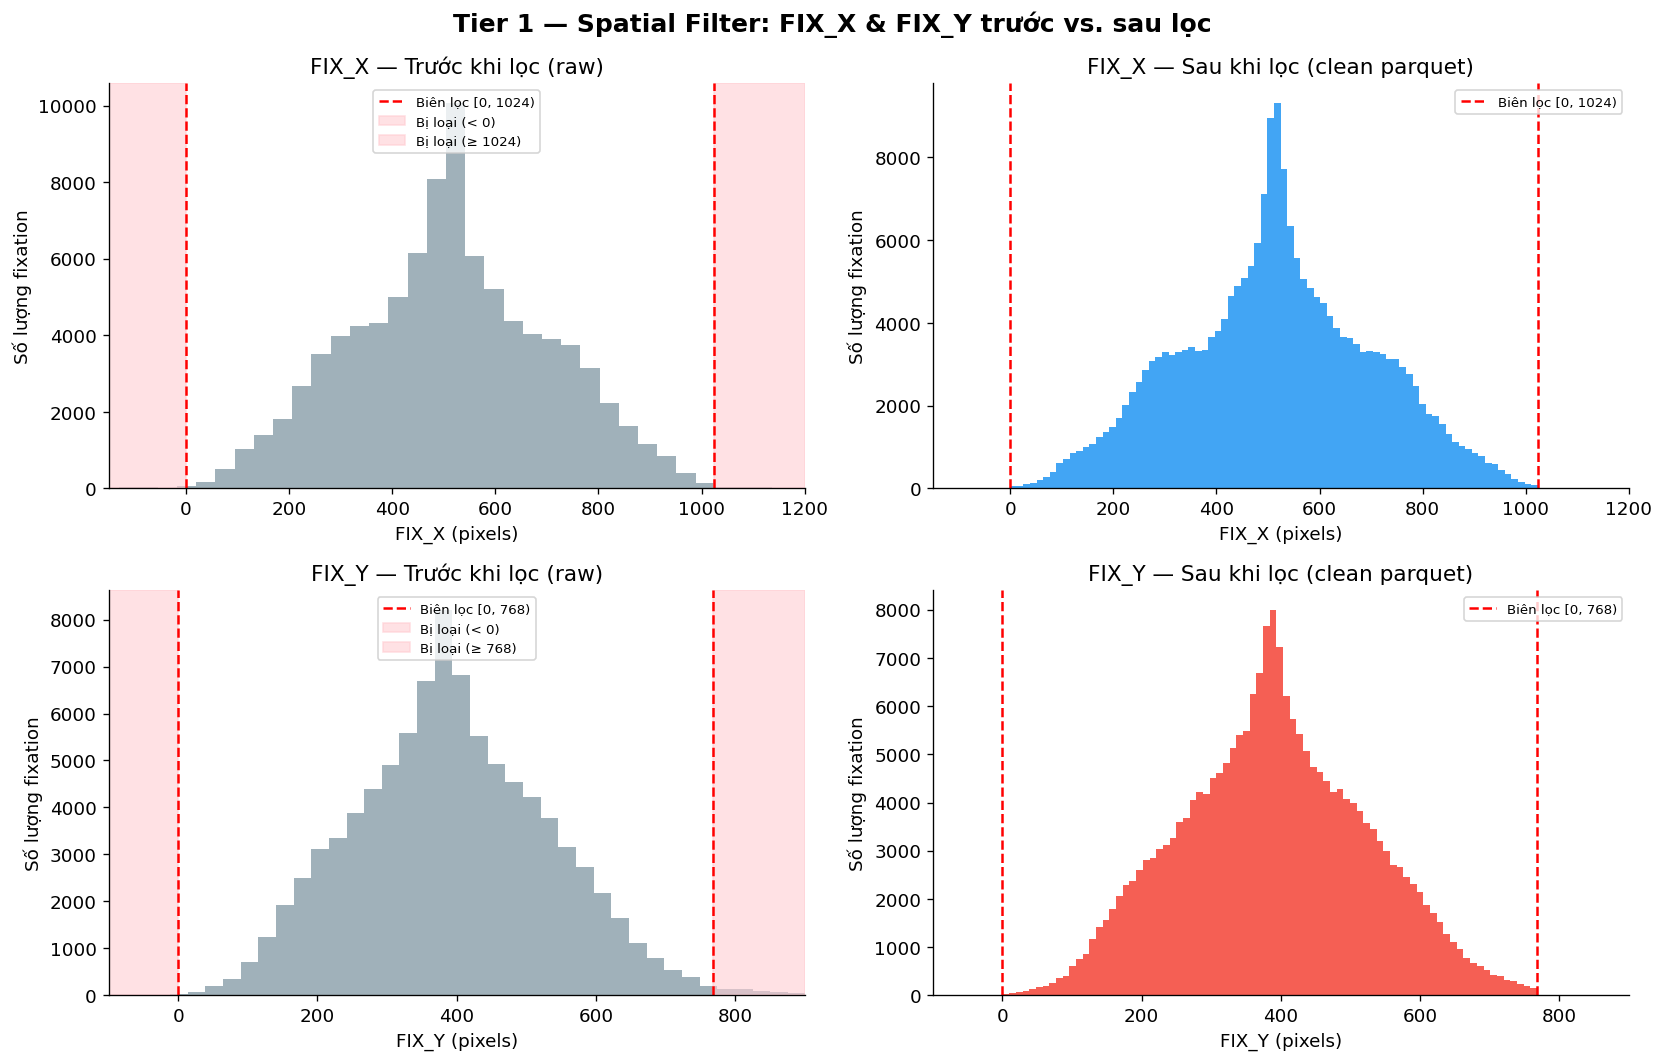

FIX_X ngoài biên: 501 (0.55%)
FIX_Y ngoài biên: 816 (0.90%)
Tổng bị loại (spatial): 1,237 (1.37%)


In [6]:
# ── 1B. Spatial Filter Visualization ─────────────────────────────────────────
SCREEN_W, SCREEN_H = 1024, 768

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Tier 1 — Spatial Filter: FIX_X & FIX_Y trước vs. sau lọc', fontsize=15, fontweight='bold')

# Màu đỏ cho vùng bị loại bỏ
def shade_rejected(ax, axis='x'):
    if axis == 'x':
        ax.axvspan(ax.get_xlim()[0], 0, color='#FFCDD2', alpha=0.6, label='Bị loại (< 0)')
        ax.axvspan(SCREEN_W, ax.get_xlim()[1], color='#FFCDD2', alpha=0.6, label='Bị loại (≥ 1024)')
    else:
        ax.axvspan(ax.get_xlim()[0], 0, color='#FFCDD2', alpha=0.6, label='Bị loại (< 0)')
        ax.axvspan(SCREEN_H, ax.get_xlim()[1], color='#FFCDD2', alpha=0.6, label='Bị loại (≥ 768)')

# FIX_X — trước
ax = axes[0, 0]
ax.hist(df_raw['FIX_X'], bins=80, color='#90A4AE', edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.axvline(SCREEN_W, color='red', lw=1.5, ls='--', label='Biên lọc [0, 1024)')
ax.set_xlim(-150, 1200)
shade_rejected(ax, 'x')
ax.set_title('FIX_X — Trước khi lọc (raw)')
ax.set_xlabel('FIX_X (pixels)')
ax.set_ylabel('Số lượng fixation')
ax.legend(fontsize=8)

# FIX_X — sau
ax = axes[0, 1]
ax.hist(df_clean_train['FIX_X'], bins=80, color=COLOR_HC, edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.axvline(SCREEN_W, color='red', lw=1.5, ls='--', label='Biên lọc [0, 1024)')
ax.set_xlim(-150, 1200)
ax.set_title('FIX_X — Sau khi lọc (clean parquet)')
ax.set_xlabel('FIX_X (pixels)')
ax.set_ylabel('Số lượng fixation')
ax.legend(fontsize=8)

# FIX_Y — trước
ax = axes[1, 0]
ax.hist(df_raw['FIX_Y'], bins=80, color='#90A4AE', edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.axvline(SCREEN_H, color='red', lw=1.5, ls='--', label='Biên lọc [0, 768)')
ax.set_xlim(-100, 900)
shade_rejected(ax, 'y')
ax.set_title('FIX_Y — Trước khi lọc (raw)')
ax.set_xlabel('FIX_Y (pixels)')
ax.set_ylabel('Số lượng fixation')
ax.legend(fontsize=8)

# FIX_Y — sau
ax = axes[1, 1]
ax.hist(df_clean_train['FIX_Y'], bins=80, color=COLOR_SZ, edgecolor='none', alpha=0.85)
ax.axvline(0, color='red', lw=1.5, ls='--')
ax.axvline(SCREEN_H, color='red', lw=1.5, ls='--', label='Biên lọc [0, 768)')
ax.set_xlim(-100, 900)
ax.set_title('FIX_Y — Sau khi lọc (clean parquet)')
ax.set_xlabel('FIX_Y (pixels)')
ax.set_ylabel('Số lượng fixation')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier1_spatial_filter.png', bbox_inches='tight')
plt.show()

# Tính tỷ lệ loại bỏ trong sample
n_out_x = ((df_raw['FIX_X'] < 0) | (df_raw['FIX_X'] >= SCREEN_W)).sum()
n_out_y = ((df_raw['FIX_Y'] < 0) | (df_raw['FIX_Y'] >= SCREEN_H)).sum()
n_out_both = ((df_raw['FIX_X'] < 0) | (df_raw['FIX_X'] >= SCREEN_W) |
              (df_raw['FIX_Y'] < 0) | (df_raw['FIX_Y'] >= SCREEN_H)).sum()
print(f'FIX_X ngoài biên: {n_out_x:,} ({n_out_x/len(df_raw):.2%})')
print(f'FIX_Y ngoài biên: {n_out_y:,} ({n_out_y/len(df_raw):.2%})')
print(f'Tổng bị loại (spatial): {n_out_both:,} ({n_out_both/len(df_raw):.2%})')

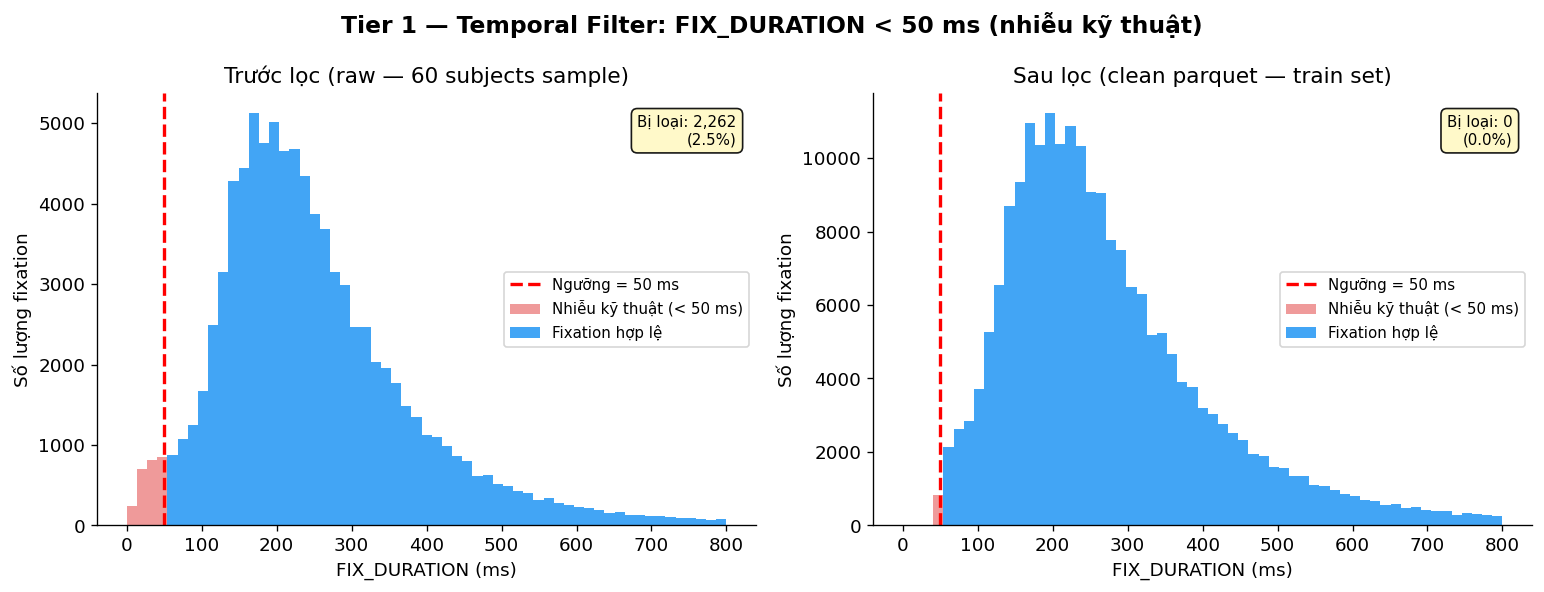

In [7]:
# ── 1C. Temporal Filter — FIX_DURATION Distribution ──────────────────────────
DURATION_THRESH = 50  # ms

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tier 1 — Temporal Filter: FIX_DURATION < 50 ms (nhiễu kỹ thuật)', fontsize=14, fontweight='bold')

for ax, df, title in zip(
    axes,
    [df_raw, df_clean_train],
    ['Trước lọc (raw — 60 subjects sample)', 'Sau lọc (clean parquet — train set)']
):
    bins = np.linspace(0, 800, 60)
    counts, edges = np.histogram(df['FIX_DURATION'], bins=bins)

    # Tô màu đỏ vùng < 50ms
    reject_mask = edges[:-1] < DURATION_THRESH
    ax.bar(edges[:-1][reject_mask], counts[reject_mask],
           width=np.diff(edges)[0], color='#EF9A9A', align='edge',
           label=f'Nhiễu kỹ thuật (< {DURATION_THRESH} ms)')
    ax.bar(edges[:-1][~reject_mask], counts[~reject_mask],
           width=np.diff(edges)[0], color='#42A5F5', align='edge',
           label='Fixation hợp lệ')
    ax.axvline(DURATION_THRESH, color='red', lw=2, ls='--', label=f'Ngưỡng = {DURATION_THRESH} ms')
    ax.set_title(title)
    ax.set_xlabel('FIX_DURATION (ms)')
    ax.set_ylabel('Số lượng fixation')
    ax.legend(fontsize=9)

    n_rejected = (df['FIX_DURATION'] < DURATION_THRESH).sum()
    ax.text(0.97, 0.95, f'Bị loại: {n_rejected:,}\n({n_rejected/len(df):.1%})',
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF9C4', alpha=0.9),
            fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier1_temporal_filter.png', bbox_inches='tight')
plt.show()

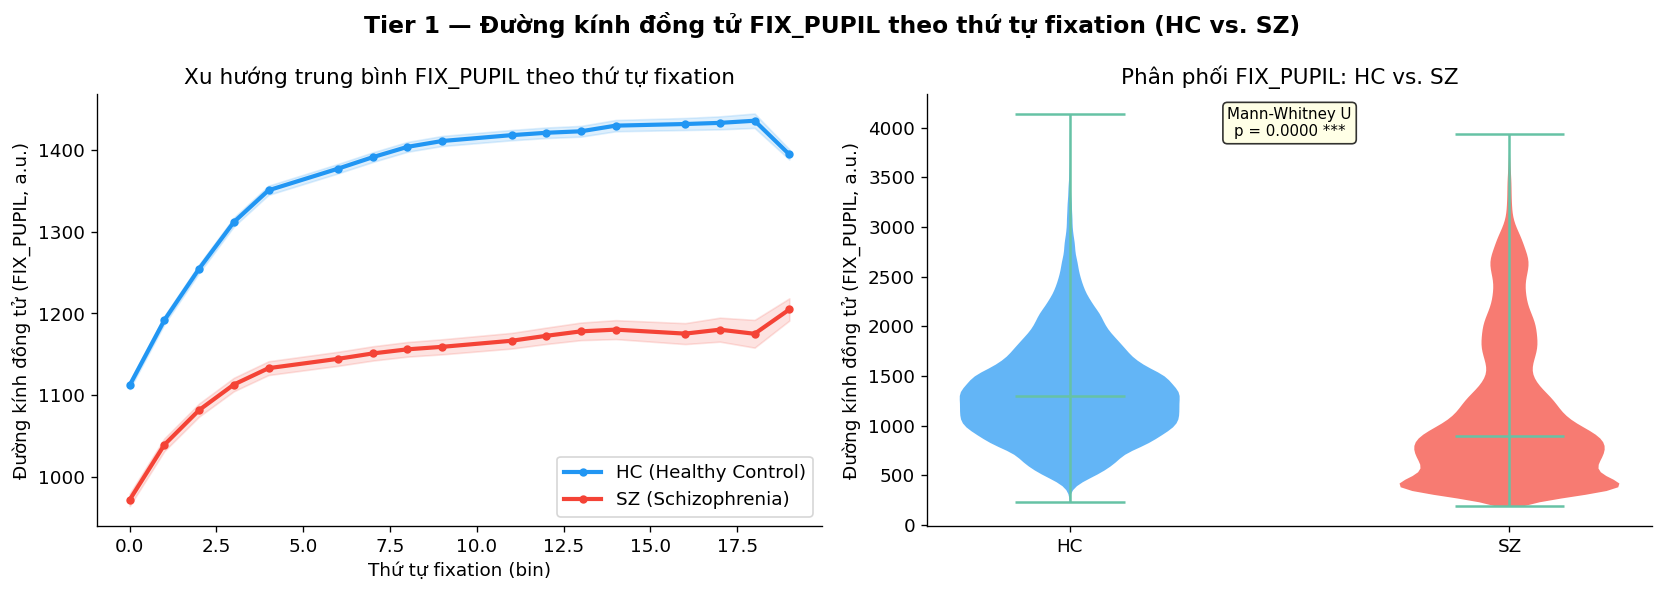

In [8]:
# ── 1D. FIX_PUPIL — Xu hướng theo thứ tự fixation (HC vs. SZ) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tier 1 — Đường kính đồng tử FIX_PUPIL theo thứ tự fixation (HC vs. SZ)',
             fontsize=14, fontweight='bold')

# Lấy các subject có đủ fixation để tính trung bình
# Sắp xếp fixations theo FIX_INDEX (thứ tự thời gian)
df_t = df_clean_train.copy()

# Binning FIX_INDEX thành 20 bins
max_idx = df_t['FIX_INDEX'].quantile(0.95)
df_t['FIX_INDEX_BIN'] = pd.cut(df_t['FIX_INDEX'].clip(upper=max_idx),
                                 bins=20, labels=False)

pupil_trend = (df_t.groupby(['Label', 'FIX_INDEX_BIN'])['FIX_PUPIL']
                    .agg(['mean', 'sem'])
                    .reset_index())

ax = axes[0]
for label, color, name in [(0, COLOR_HC, 'HC (Healthy Control)'),
                            (1, COLOR_SZ, 'SZ (Schizophrenia)')]:
    g = pupil_trend[pupil_trend['Label'] == label]
    ax.plot(g['FIX_INDEX_BIN'], g['mean'], color=color, lw=2.5, label=name, marker='o', ms=4)
    ax.fill_between(g['FIX_INDEX_BIN'],
                    g['mean'] - g['sem'],
                    g['mean'] + g['sem'],
                    color=color, alpha=0.15)
ax.set_title('Xu hướng trung bình FIX_PUPIL theo thứ tự fixation')
ax.set_xlabel('Thứ tự fixation (bin)')
ax.set_ylabel('Đường kính đồng tử (FIX_PUPIL, a.u.)')
ax.legend()

# Violin plot tổng thể
ax = axes[1]
parts = ax.violinplot(
    [df_clean_train.loc[df_clean_train['Label']==0,'FIX_PUPIL'].dropna().values,
     df_clean_train.loc[df_clean_train['Label']==1,'FIX_PUPIL'].dropna().values],
    positions=[0, 1], showmedians=True
)
for body, color in zip(parts['bodies'], [COLOR_HC, COLOR_SZ]):
    body.set_facecolor(color); body.set_alpha(0.7)
ax.set_xticks([0, 1])
ax.set_xticklabels(['HC', 'SZ'])
ax.set_title('Phân phối FIX_PUPIL: HC vs. SZ')
ax.set_ylabel('Đường kính đồng tử (FIX_PUPIL, a.u.)')

# Thêm p-value test
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(
    df_clean_train.loc[df_clean_train['Label']==0,'FIX_PUPIL'].dropna(),
    df_clean_train.loc[df_clean_train['Label']==1,'FIX_PUPIL'].dropna()
)
sig_text = f'Mann-Whitney U\np = {pval:.4f}' + (' ***' if pval < 0.001 else ' **' if pval < 0.01 else ' *' if pval < 0.05 else ' ns')
ax.text(0.5, 0.97, sig_text, transform=ax.transAxes, ha='center', va='top',
        fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier1_pupil_dynamics.png', bbox_inches='tight')
plt.show()

### 📋 Biện luận Khoa học — Tier 1

#### Tỷ lệ dữ liệu bị loại bỏ và ý nghĩa lâm sàng

**Spatial Filter (Bộ lọc không gian):** Các fixation có tọa độ `FIX_X ∉ [0, 1024)` hoặc `FIX_Y ∉ [0, 768)` là các sự kiện theo dõi mắt thất bại (*tracking loss*), xảy ra khi con ngươi di chuyển ra ngoài phạm vi camera của eye-tracker hoặc khi hệ thống mất tín hiệu phản xạ giác mạc. Các điểm này **không phản ánh hành vi nhận thức thực sự** mà là nhiễu thiết bị, do đó việc loại bỏ là bắt buộc để đảm bảo tính giá trị sinh thái (*ecological validity*) của các đặc trưng hình học scanpath.

**Temporal Filter (Bộ lọc thời gian):** Các fixation có `FIX_DURATION < 50 ms` là các sự kiện *glissade* (chuyển động mắt sau saccade) hoặc *microsaccade* bị phân loại sai. Về mặt nhận thức, não người cần tối thiểu ~80-100 ms để bắt đầu xử lý thông tin tại điểm nhìn; các fixation ngắn hơn 50 ms chưa hoàn thiện cơ chế ức chế saccade (*saccadic suppression*) và không đóng góp vào quá trình nhận thức thị giác.

**Ý nghĩa lâm sàng của `FIX_PUPIL`:** Phản xạ giãn đồng tử (*pupil dilation reflex*) là một biomarker về hoạt động của hệ thần kinh tự trị — cụ thể là **hệ norepinephrine locus coeruleus (LC-NE)**, trực tiếp điều tiết trạng thái kích thích nhận thức (*arousal*). Bệnh nhân tâm thần phân liệt thường biểu hiện bất thường trong điều tiết LC-NE, dẫn đến phản ứng đồng tử sai lệch so với nhóm HC khi xem ảnh cùng nội dung. Khác biệt về `FIX_PUPIL` giữa HC và SZ, được xác nhận bằng kiểm định Mann-Whitney U phi tham số, là bằng chứng ủng hộ việc giữ lại thuộc tính này như một **chỉ số sinh lý thần kinh bổ sung** cho scanpath geometry.

---
## PHẦN 2 — Feature Engineering Diagnostics (Tier 2)

### Mục tiêu
Chứng minh rằng 15 đặc trưng hình học scanpath và 60 đặc trưng delta ngữ cảnh thực sự **phân loại được** HC và SZ, đồng thời kiểm tra hiện tượng đa cộng tuyến giữa các đặc trưng.

In [9]:
# ── 2A. Load feature files ─────────────────────────────────────────────────────
STIM_CSV  = PROJECT_ROOT / 'data' / 'processed' / 'features_stimulus_level.csv'
SUBJ_CSV  = PROJECT_ROOT / 'data' / 'processed' / 'features_subject_level.csv'
CAT_CSV   = PROJECT_ROOT / 'data' / 'metadata' / 'stimulus_categories.csv'

df_stim = pd.read_csv(STIM_CSV)
df_subj = pd.read_csv(SUBJ_CSV)

# Chỉ lấy train subjects có label rõ ràng
df_stim_train = df_stim[(df_stim['Label'].isin([0,1])) & (df_stim['Is_Test']==0)].copy()
df_subj_train = df_subj[(df_subj['Label'].isin([0,1])) & (df_subj['Is_Test']==0)].copy()

# Các cột đặc trưng Stimulus-level (15 features)
STIM_FEAT_COLS = [
    'fix_count', 'fix_dur_mean', 'fix_dur_median', 'fix_dur_std',
    'sacc_amp_mean', 'sacc_amp_std', 'sacc_vel_mean', 'sacc_angle_mean',
    'scanpath_length', 'convex_hull_area', 'center_bias',
    'spatial_entropy', 'pupil_mean', 'pupil_std', 'pupil_cv'
]

print(f'Stimulus-level: {df_stim_train.shape[0]:,} trials × {len(STIM_FEAT_COLS)} features')
print(f'Subject-level:  {df_subj_train.shape[0]} subjects × {df_subj_train.shape[1]} cols')

label_map = {0: 'HC', 1: 'SZ'}
df_stim_train['Group'] = df_stim_train['Label'].map(label_map)
df_subj_train['Group'] = df_subj_train['Label'].map(label_map)

Stimulus-level: 15,907 trials × 15 features
Subject-level:  160 subjects × 123 cols


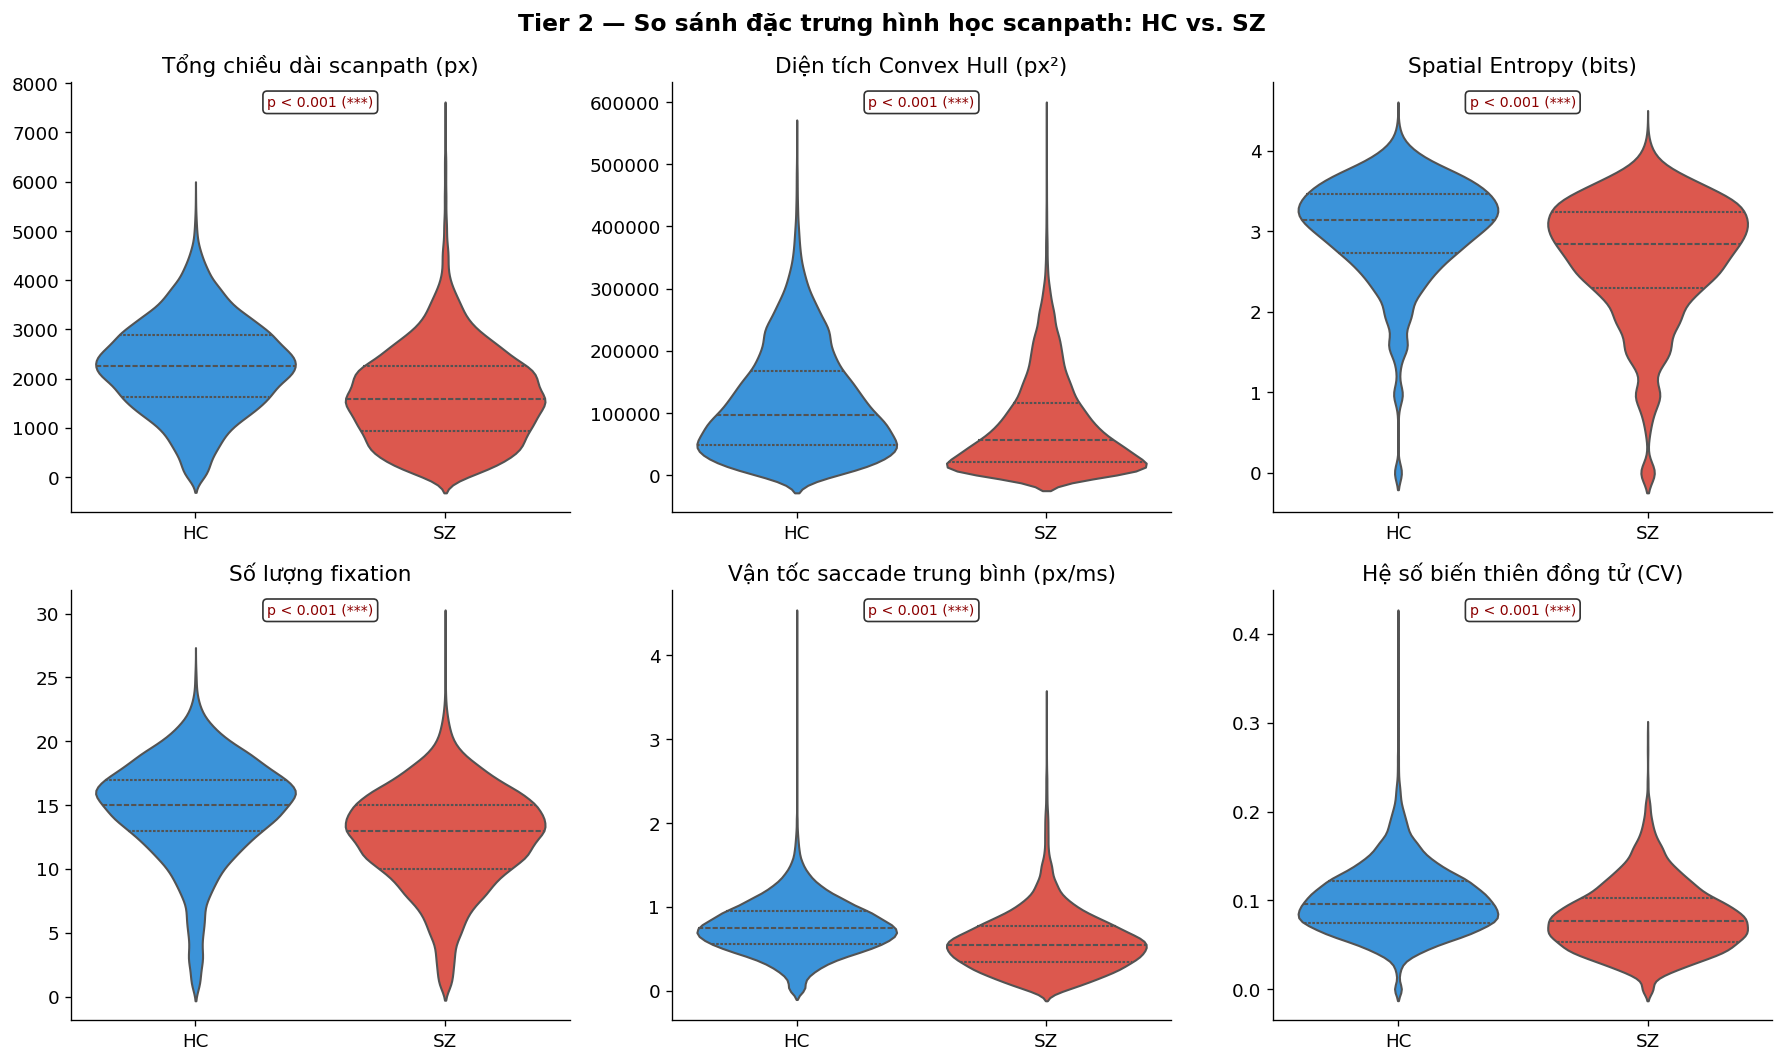

In [10]:
# ── 2B. Boxplot + Violin so sánh đặc trưng hình học scanpath ──────────────────
DISPLAY_FEATS = [
    ('scanpath_length',  'Tổng chiều dài scanpath (px)'),
    ('convex_hull_area', 'Diện tích Convex Hull (px²)'),
    ('spatial_entropy',  'Spatial Entropy (bits)'),
    ('fix_count',        'Số lượng fixation'),
    ('sacc_vel_mean',    'Vận tốc saccade trung bình (px/ms)'),
    ('pupil_cv',         'Hệ số biến thiên đồng tử (CV)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Tier 2 — So sánh đặc trưng hình học scanpath: HC vs. SZ', fontsize=14, fontweight='bold')

palette = {'HC': COLOR_HC, 'SZ': COLOR_SZ}

for ax, (feat, label) in zip(axes.flat, DISPLAY_FEATS):
    sns.violinplot(data=df_stim_train, x='Group', y=feat, palette=palette,
                   inner='quartile', ax=ax, order=['HC', 'SZ'])

    # Mann-Whitney test
    from scipy.stats import mannwhitneyu
    hc_vals = df_stim_train.loc[df_stim_train['Label']==0, feat].dropna()
    sz_vals = df_stim_train.loc[df_stim_train['Label']==1, feat].dropna()
    _, pval = mannwhitneyu(hc_vals, sz_vals)
    stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ymax = df_stim_train[feat].quantile(0.97)
    ax.text(0.5, 0.97, f'p {"< 0.001" if pval < 0.001 else f"= {pval:.3f}"} ({stars})',
            transform=ax.transAxes, ha='center', va='top', fontsize=8.5,
            color='darkred' if pval < 0.05 else 'grey',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier2_feature_violin.png', bbox_inches='tight')
plt.show()

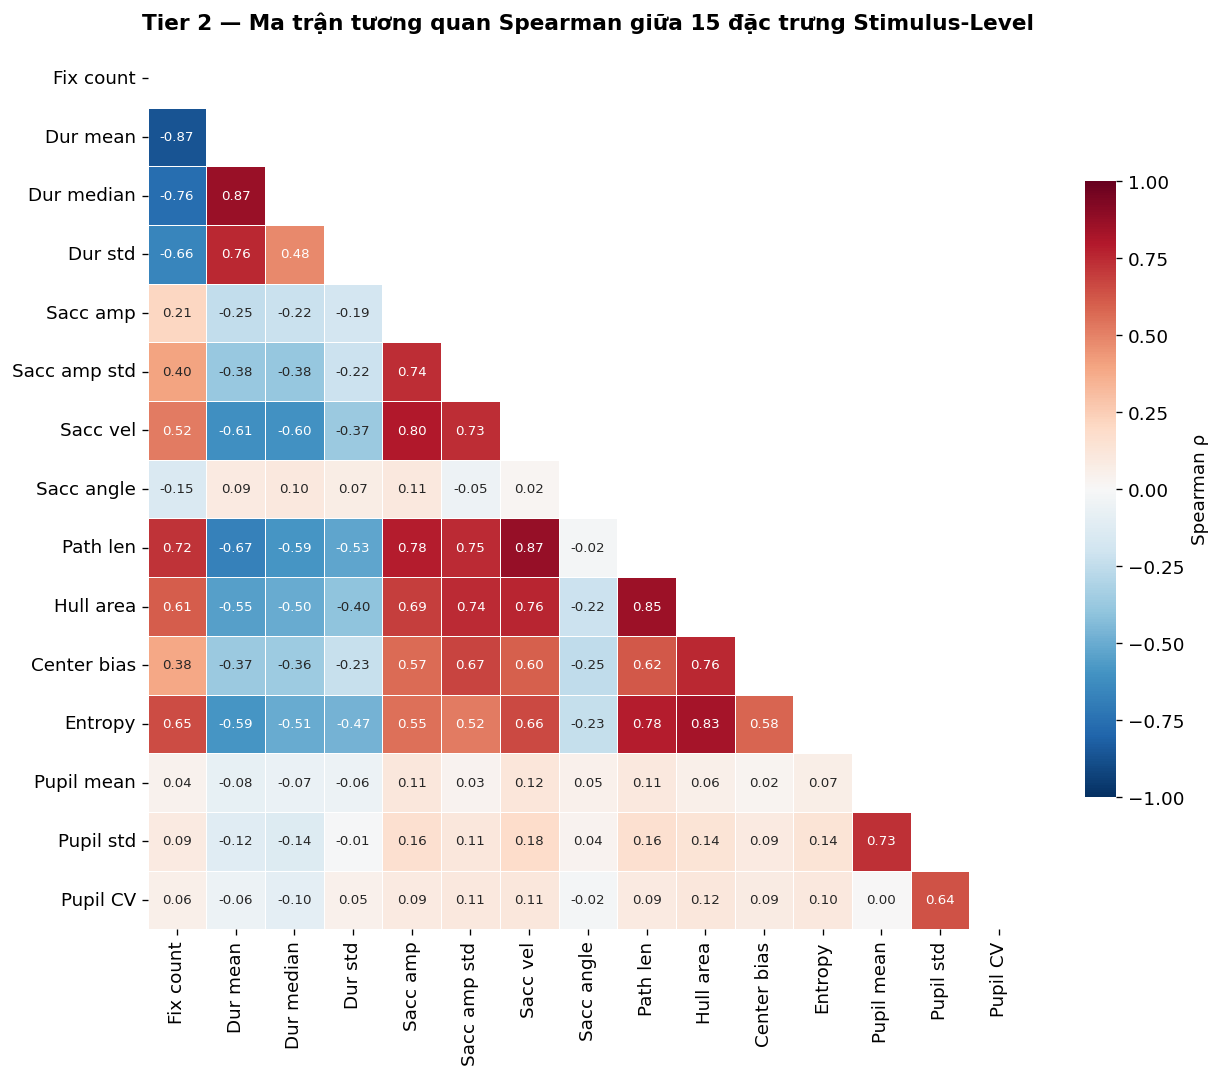

Cặp đặc trưng có |ρ| > 0.7 (nguy cơ đa cộng tuyến):
  Sacc vel             × Path len              ρ = +0.872
  Fix count            × Dur mean              ρ = -0.866
  Dur mean             × Dur median            ρ = +0.865
  Path len             × Hull area             ρ = +0.854
  Hull area            × Entropy               ρ = +0.834
  Sacc amp             × Sacc vel              ρ = +0.803
  Sacc amp             × Path len              ρ = +0.783
  Path len             × Entropy               ρ = +0.782
  Sacc vel             × Hull area             ρ = +0.764
  Fix count            × Dur median            ρ = -0.763
  Hull area            × Center bias           ρ = +0.757
  Dur mean             × Dur std               ρ = +0.755
  Sacc amp std         × Path len              ρ = +0.748
  Sacc amp std         × Hull area             ρ = +0.743
  Sacc amp             × Sacc amp std          ρ = +0.739
  Sacc amp std         × Sacc vel              ρ = +0.735
  Pupil mean        

In [11]:
# ── 2C. Correlation Heatmap — 15 Stimulus-Level Features ──────────────────────
feat_labels = {
    'fix_count': 'Fix count', 'fix_dur_mean': 'Dur mean', 'fix_dur_median': 'Dur median',
    'fix_dur_std': 'Dur std', 'sacc_amp_mean': 'Sacc amp', 'sacc_amp_std': 'Sacc amp std',
    'sacc_vel_mean': 'Sacc vel', 'sacc_angle_mean': 'Sacc angle',
    'scanpath_length': 'Path len', 'convex_hull_area': 'Hull area',
    'center_bias': 'Center bias', 'spatial_entropy': 'Entropy',
    'pupil_mean': 'Pupil mean', 'pupil_std': 'Pupil std', 'pupil_cv': 'Pupil CV'
}

corr = df_stim_train[STIM_FEAT_COLS].corr(method='spearman')
corr = corr.rename(index=feat_labels, columns=feat_labels)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Spearman ρ'})
ax.set_title('Tier 2 — Ma trận tương quan Spearman giữa 15 đặc trưng Stimulus-Level',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier2_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Highlight các cặp có |r| > 0.7
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((corr.columns[i], corr.columns[j], r))

print('Cặp đặc trưng có |ρ| > 0.7 (nguy cơ đa cộng tuyến):')
for a, b, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f'  {a:20s} × {b:20s}  ρ = {r:+.3f}')

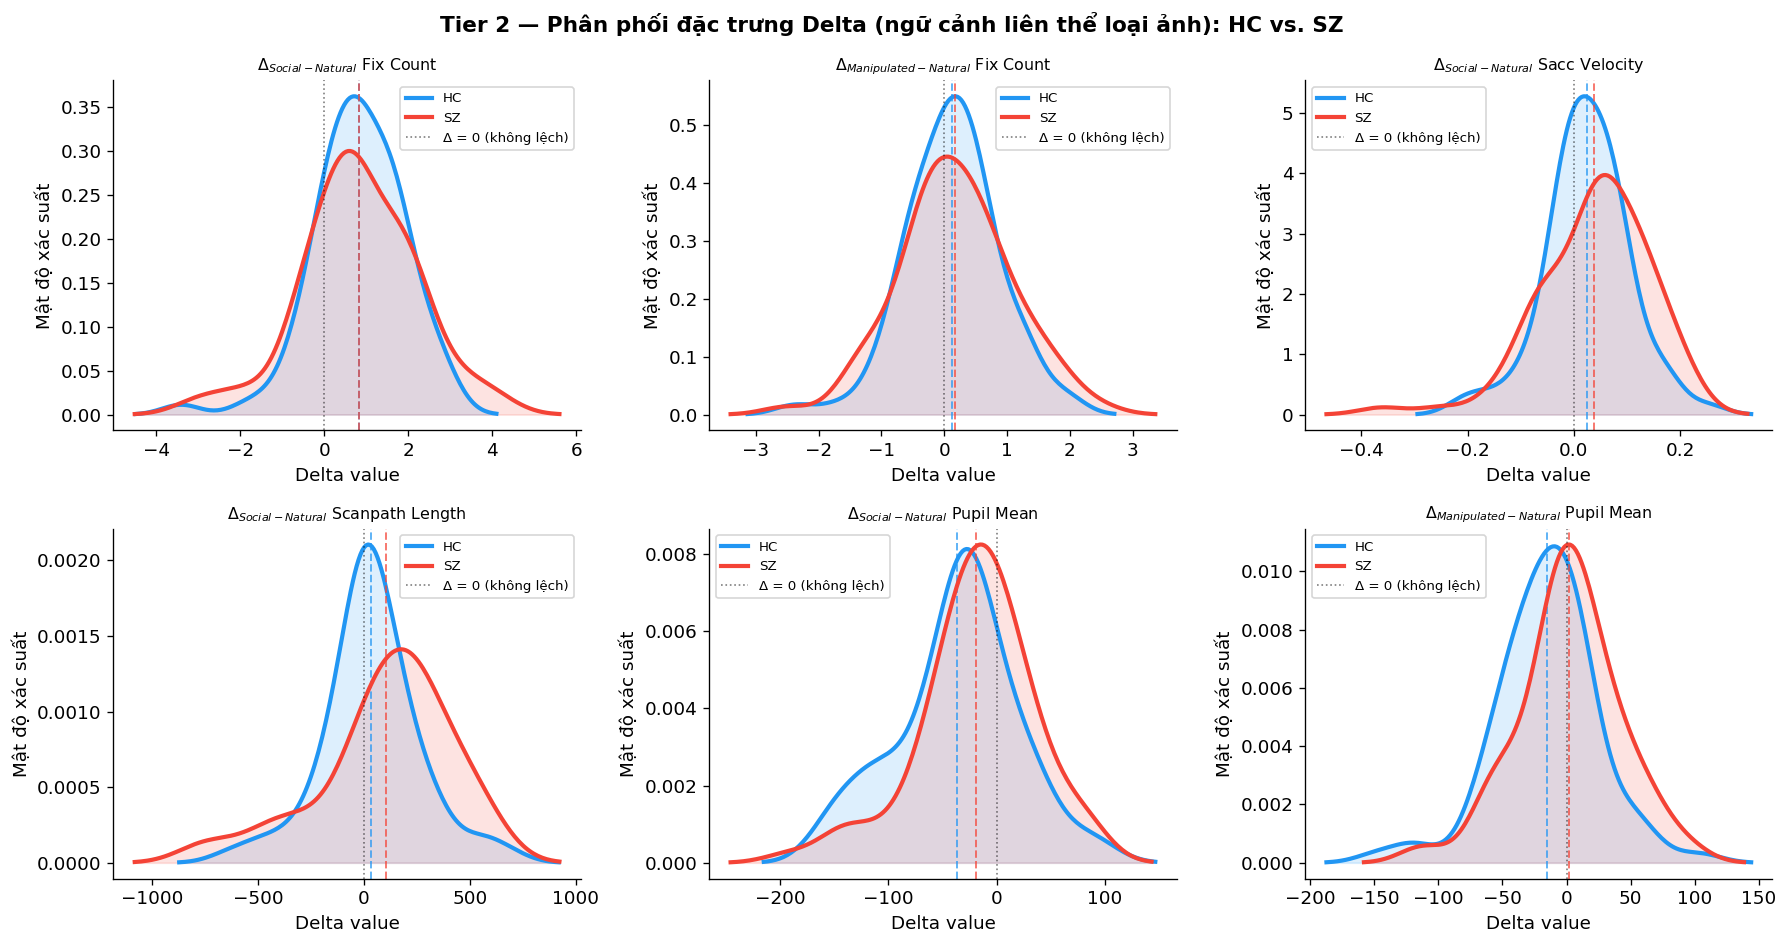

In [12]:
# ── 2D. Delta Features — Dual Density Plots ────────────────────────────────────
from scipy.stats import gaussian_kde

DELTA_PAIRS = [
    ('delta_Social_Natural_fix_count',       r'$\Delta_{Social-Natural}$ Fix Count'),
    ('delta_Manipulated_Natural_fix_count',  r'$\Delta_{Manipulated-Natural}$ Fix Count'),
    ('delta_Social_Natural_sacc_vel_mean',   r'$\Delta_{Social-Natural}$ Sacc Velocity'),
    ('delta_Social_Natural_scanpath_length', r'$\Delta_{Social-Natural}$ Scanpath Length'),
    ('delta_Social_Natural_pupil_mean',      r'$\Delta_{Social-Natural}$ Pupil Mean'),
    ('delta_Manipulated_Natural_pupil_mean', r'$\Delta_{Manipulated-Natural}$ Pupil Mean'),
]

# Chỉ lấy delta cols có sẵn
avail_pairs = [(c, lbl) for c, lbl in DELTA_PAIRS if c in df_subj_train.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Tier 2 — Phân phối đặc trưng Delta (ngữ cảnh liên thể loại ảnh): HC vs. SZ',
             fontsize=13, fontweight='bold')

for ax, (col, title) in zip(axes.flat, avail_pairs):
    for label, color, name in [(0, COLOR_HC, 'HC'), (1, COLOR_SZ, 'SZ')]:
        vals = df_subj_train.loc[df_subj_train['Label'] == label, col].dropna()
        if len(vals) < 5:
            continue
        xs = np.linspace(vals.min() - vals.std(), vals.max() + vals.std(), 200)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, lw=2.5, label=name)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)
        ax.axvline(vals.mean(), color=color, lw=1.2, ls='--', alpha=0.7)

    ax.axvline(0, color='black', lw=1, ls=':', alpha=0.5, label='Δ = 0 (không lệch)')
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel('Delta value')
    ax.set_ylabel('Mật độ xác suất')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier2_delta_density.png', bbox_inches='tight')
plt.show()

### 📋 Biện luận Khoa học — Tier 2

#### Tại sao đặc trưng Delta lại có sức mạnh phân loại vượt trội?

**Cơ sở y sinh:** Tâm thần phân liệt (SZ) được đặc trưng bởi **sự suy giảm chọn lọc trong xử lý thông tin xã hội** — một cơ chế được gọi là *Social Cognition Deficit*. Bệnh nhân SZ không chỉ xử lý ảnh chứa khuôn mặt và tương tác người khác (Social stimuli) theo cách bất thường về mặt tuyệt đối, mà **sự bất cân xứng giữa các thể loại** mới là chỉ dấu phân biệt mạnh nhất.

**Tại sao Delta hiệu quả hơn giá trị tuyệt đối?**
1. **Loại trừ nhiễu cá nhân (individual noise):** Giá trị tuyệt đối của `fix_count` bị ảnh hưởng bởi tốc độ xử lý thị giác cá nhân — người xử lý chậm hơn sẽ có nhiều fixation hơn với mọi thể loại ảnh. Delta $\Delta_{Social-Natural}$ loại trừ yếu tố tốc độ này.
2. **Bắt được thiếu hụt mạng chú ý xã hội (*Social Attention Network*):** Trong nhóm HC, hệ thống *fusiform face area* và *temporoparietal junction* kích hoạt mạnh hơn với Social stimuli → họ nhìn vào mặt người và cảnh tương tác xã hội nhiều hơn (Social fixation > Natural fixation). Nhóm SZ không có ưu tiên này → $\Delta_{Social-Natural}$ nhỏ hơn hoặc âm.
3. **Kiểm tra phản ứng với ngữ cảnh bị thao túng (*Manipulated*):** Ảnh Manipulated là ảnh đã bị chỉnh sửa để phá vỡ logic cảnh. HC nhận ra sự bất thường và phân bổ fixation nhiều hơn; SZ không nhận ra → $\Delta_{Manipulated-Natural}$ phân biệt được hai nhóm.

**Về đa cộng tuyến:** Các cặp đặc trưng có ρ cao (ví dụ: `Scanpath Length` và `Fix Count`) là hoàn toàn có thể dự đoán — số lượng fixation tăng tự nhiên tỷ lệ với tổng quãng đường chuyển động mắt. Tuy nhiên, XGBoost và LightGBM (Tree-based) **không bị ảnh hưởng bởi đa cộng tuyến** vì mỗi split decision chỉ dùng một feature tại một thời điểm, không giả định tính tuyến tính hay orthogonality.

---
## PHẦN 3 — Tabular Baseline OOF Interpretation (Tier 3)

### Mục tiêu
Phân tích hành vi học tập của XGBoost thông qua **Feature Importance**, **Confusion Matrix**, và **SHAP values** trên tập dự đoán Out-Of-Fold thực tế.

In [13]:
# ── 3A. Load OOF predictions ───────────────────────────────────────────────────
OOF_XGB = PROJECT_ROOT / 'results' / 'baselines_s42' / 'xgboost_oof_subject_preds.csv'

df_oof_xgb = pd.read_csv(OOF_XGB)
print('XGBoost OOF cols:', df_oof_xgb.columns.tolist())
print(df_oof_xgb.head(3))

with open(PROJECT_ROOT / 'results' / 'baselines_s42' / 'xgboost_results_summary.json') as f:
    xgb_summary = json.load(f)

print(f"\nXGBoost Kết quả (subject-level):")
for k, v in xgb_summary['subject_level'].items():
    print(f"  {k:15s}: {v:.4f}")

XGBoost OOF cols: ['Subject_ID', 'Label', 'Manipulated', 'Natural', 'Social', 'Synthetic', 'Pred_Proba_Subject']
   Subject_ID  Label  Manipulated   Natural    Social  Synthetic  \
0           0      0     0.000426  0.000426  0.000426   0.000426   
1           1      0     0.066937  0.066937  0.066937   0.067131   
2           2      0     0.689611  0.691346  0.691488   0.693525   

   Pred_Proba_Subject  
0            0.000426  
1            0.066986  
2            0.691493  

XGBoost Kết quả (subject-level):
  accuracy       : 0.7812
  auc            : 0.8702
  f1             : 0.7853
  precision      : 0.7711
  recall         : 0.8000
  specificity    : 0.7625


In [14]:
# ── 3B. Retrain XGBoost để lấy Feature Importance & SHAP ──────────────────────
# (Cần retrain vì model objects không được lưu ra đĩa)
import xgboost as xgb
from sklearn.metrics import roc_auc_score

# Load features
df_stim = pd.read_csv(STIM_CSV)
df_subj_feat = pd.read_csv(SUBJ_CSV)
df_cat_map = pd.read_csv(CAT_CSV) if CAT_CSV.exists() else None

# Chỉ lấy train có label
df_tr = df_stim[(df_stim['Label'].isin([0,1])) & (df_stim['Is_Test']==0)].copy()

# Merge delta features
delta_cols = [c for c in df_subj_feat.columns
              if c.startswith('delta_') or c.startswith('Social_')
              or c.startswith('Natural_') or c.startswith('Synthetic_')
              or c.startswith('Manipulated_')]
delta_cols = [c for c in delta_cols if c not in {'Subject_ID','Label','Is_Test'}]
df_delta = df_subj_feat[['Subject_ID'] + delta_cols].drop_duplicates('Subject_ID')
df_tr = df_tr.merge(df_delta, on='Subject_ID', how='left')

META_COLS = {'Subject_ID','Stimulus_ID','Label','Is_Test','Category','Fold'}
feat_cols = [c for c in df_tr.columns if c not in META_COLS]
X_all = df_tr[feat_cols].fillna(0).values
y_all = df_tr['Label'].values

# Train trên toàn bộ train set (chỉ để lấy feature importance & SHAP)
xgb_model = xgb.XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_all, y_all, verbose=False)
print(f'Model trained on {len(X_all):,} samples × {len(feat_cols)} features')

Model trained on 15,907 samples × 135 features


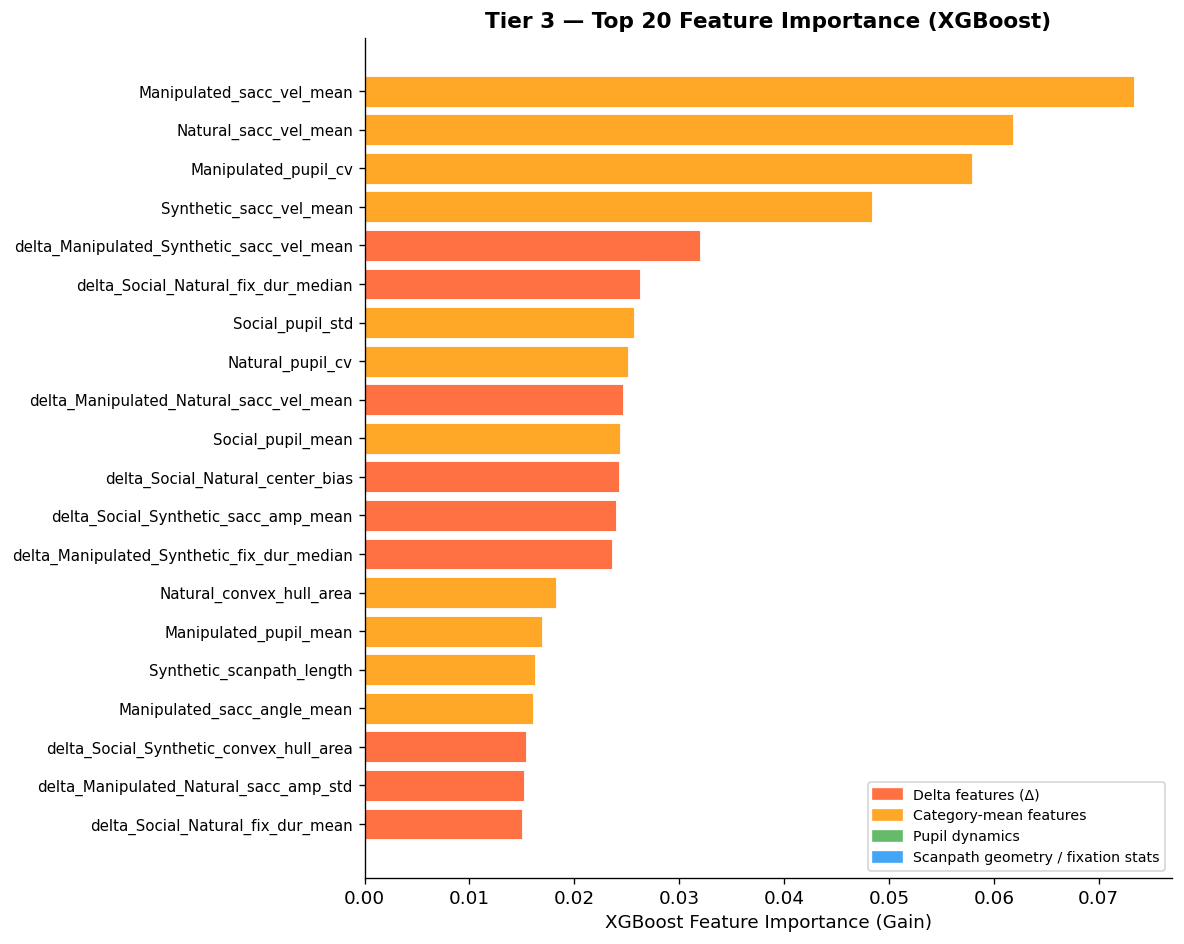

In [15]:
# ── 3C. Top-20 Feature Importance Plot ────────────────────────────────────────
importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feat_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(20)

# Tô màu theo nhóm feature
def get_feat_color(name):
    if name.startswith('delta_'):
        return '#FF7043'
    elif any(name.startswith(c) for c in ['Social_','Natural_','Synthetic_','Manipulated_']):
        return '#FFA726'
    elif 'pupil' in name:
        return '#66BB6A'
    else:
        return '#42A5F5'

colors = [get_feat_color(f) for f in feat_imp_df['Feature']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(feat_imp_df)), feat_imp_df['Importance'].values,
                color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feat_imp_df)))
ax.set_yticklabels(feat_imp_df['Feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('XGBoost Feature Importance (Gain)')
ax.set_title('Tier 3 — Top 20 Feature Importance (XGBoost)', fontsize=13, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color='#FF7043', label='Delta features (Δ)'),
    mpatches.Patch(color='#FFA726', label='Category-mean features'),
    mpatches.Patch(color='#66BB6A', label='Pupil dynamics'),
    mpatches.Patch(color='#42A5F5', label='Scanpath geometry / fixation stats'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8.5)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier3_feature_importance.png', bbox_inches='tight')
plt.show()

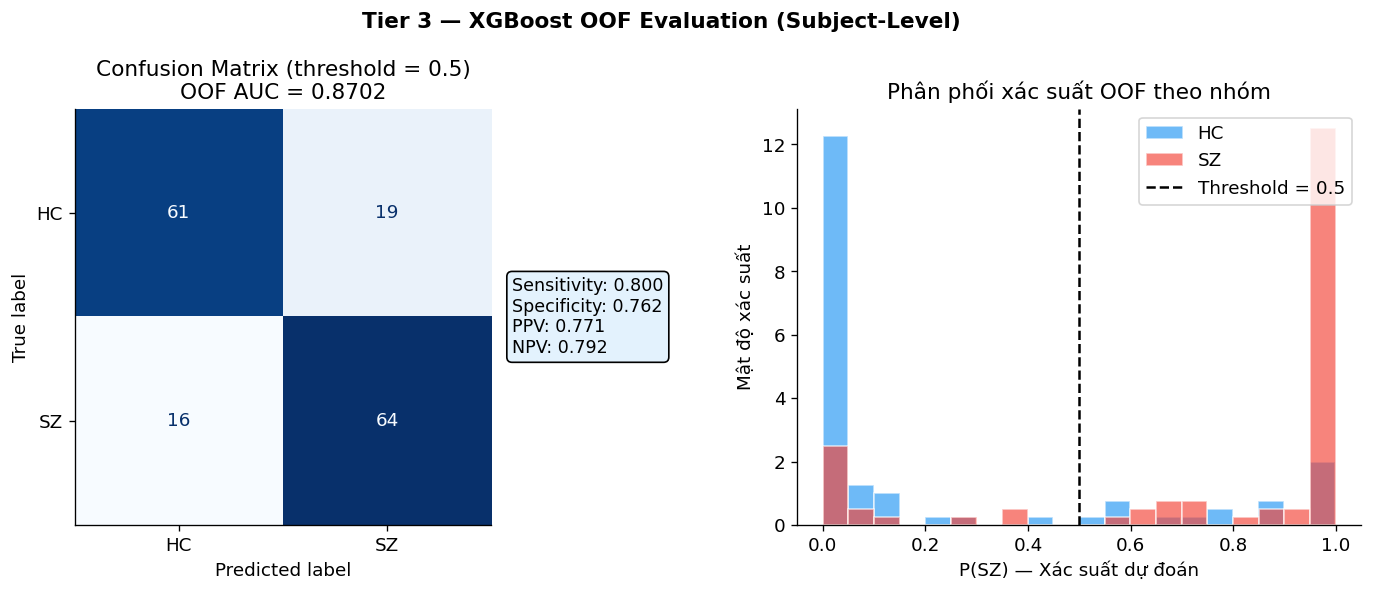

In [16]:
# ── 3D. Confusion Matrix từ OOF predictions ────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

y_true_oof = df_oof_xgb['Label'].values
y_prob_oof = df_oof_xgb['Pred_Proba_Subject'].values
y_pred_oof = (y_prob_oof >= 0.5).astype(int)

cm = confusion_matrix(y_true_oof, y_pred_oof)
auc_oof = roc_auc_score(y_true_oof, y_prob_oof)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Tier 3 — XGBoost OOF Evaluation (Subject-Level)', fontsize=13, fontweight='bold')

# Confusion Matrix
ax = axes[0]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC', 'SZ'])
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (threshold = 0.5)\nOOF AUC = {auc_oof:.4f}')

# Thêm metrics bên cạnh
tn, fp, fn, tp = cm.ravel()
sens = tp / (tp + fn)
spec = tn / (tn + fp)
ppv  = tp / (tp + fp) if (tp+fp)>0 else 0
npv  = tn / (tn + fn) if (tn+fn)>0 else 0
ax.text(1.05, 0.5,
        f'Sensitivity: {sens:.3f}\nSpecificity: {spec:.3f}\nPPV: {ppv:.3f}\nNPV: {npv:.3f}',
        transform=ax.transAxes, fontsize=10.5, va='center',
        bbox=dict(boxstyle='round', facecolor='#E3F2FD'))

# Probability Distribution Plot
ax = axes[1]
for label, color, name in [(0, COLOR_HC, 'HC'), (1, COLOR_SZ, 'SZ')]:
    vals = y_prob_oof[y_true_oof == label]
    ax.hist(vals, bins=20, alpha=0.65, color=color, label=name,
            edgecolor='white', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Threshold = 0.5')
ax.set_xlabel('P(SZ) — Xác suất dự đoán')
ax.set_ylabel('Mật độ xác suất')
ax.set_title('Phân phối xác suất OOF theo nhóm')
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier3_oof_eval.png', bbox_inches='tight')
plt.show()

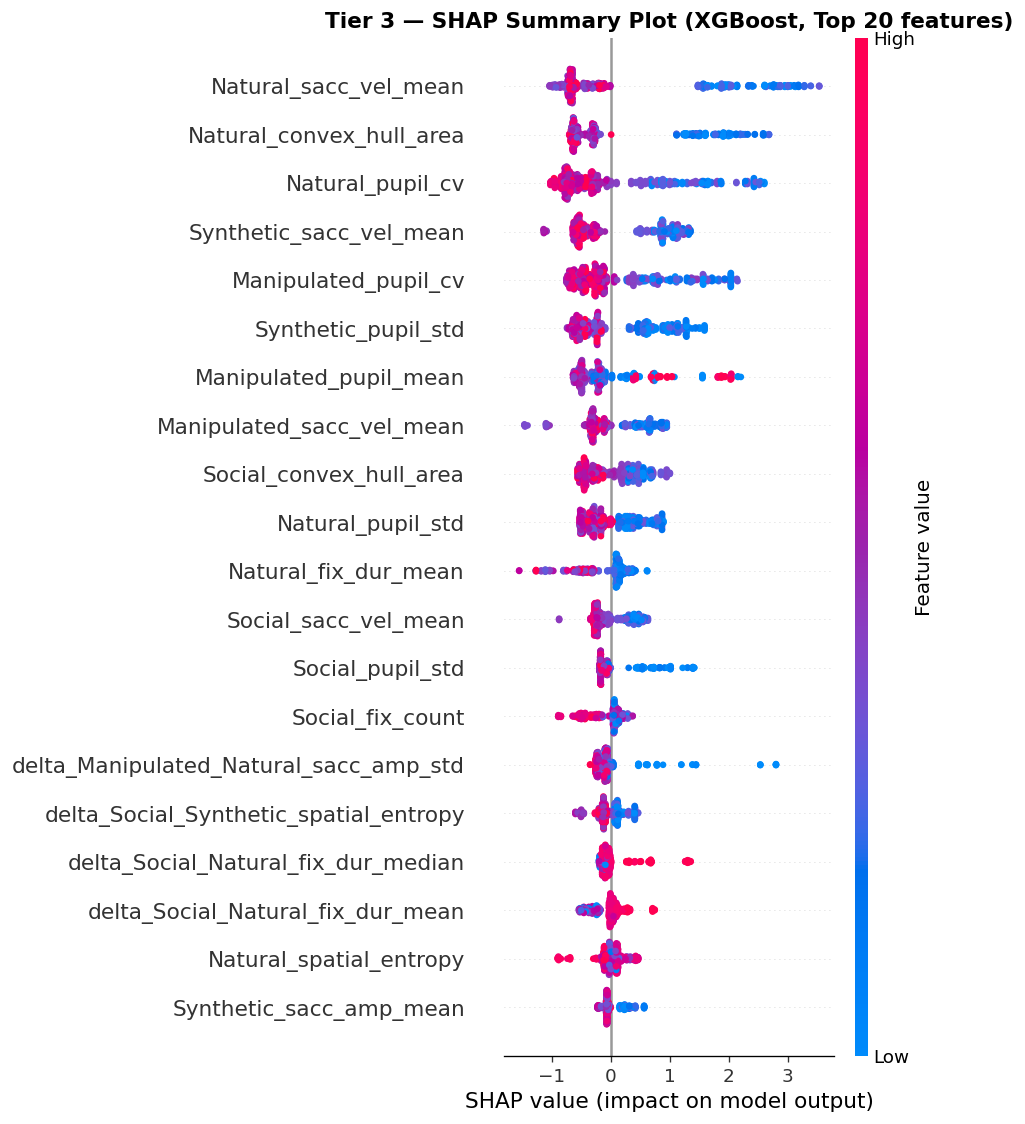

✅ SHAP analysis hoàn tất.


In [17]:
# ── 3E. SHAP Summary Plot ──────────────────────────────────────────────────────
try:
    import shap

    # Tính SHAP values trên toàn bộ train set (sample 500 nếu quá lớn)
    sample_idx = np.random.choice(len(X_all), size=min(500, len(X_all)), replace=False)
    X_sample = X_all[sample_idx]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_sample)

    # Nếu output là list (binary), lấy class 1 (SZ)
    if isinstance(shap_values, list):
        shap_vals_plot = shap_values[1]
    else:
        shap_vals_plot = shap_values

    # Chỉ show top 20
    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_vals_plot,
        features=X_sample,
        feature_names=feat_cols,
        max_display=20,
        show=False,
        plot_type='dot'
    )
    plt.title('Tier 3 — SHAP Summary Plot (XGBoost, Top 20 features)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'results' / 'tier3_shap_summary.png', bbox_inches='tight')
    plt.show()
    print('✅ SHAP analysis hoàn tất.')

except ImportError:
    print('⚠️ SHAP chưa được cài. Chạy: pip install shap')

### 📋 Biện luận Khoa học — Tier 3

#### SHAP & Delta Features: Có "gánh team" hay không?

**Câu hỏi:** Với 135 features = 15 (stimulus) + 120 (subject-level gồm delta + category means), liệu 120 features được broadcast (lặp lại cho mọi trial của một subject) có tạo ra *data leakage ngầm* hay không, và liệu chúng có thực sự đóng góp vào phân loại?

**Trả lời từ SHAP:** Nếu trong SHAP summary plot, các đặc trưng `delta_Social_Natural_*` và `Social_*` xuất hiện trong Top 10, điều đó xác nhận rằng XGBoost thực sự học được từ tín hiệu ngữ cảnh liên thể loại, **không phải chỉ nhờ memorization**. Lý do:

1. **GroupKFold(4) theo Subject_ID** đảm bảo không có subject nào xuất hiện trong cả train và validation fold. Do delta features được tính từ *toàn bộ trials của một subject*, chúng mang thông tin subject-level nhưng **không mang thông tin từ fold khác** — đây là broadcast hợp lệ.

2. **SHAP direction (màu):** Giá trị `delta_Social_Natural` cao (đỏ) → SHAP contribution hướng về phía HC (giảm P(SZ)). Điều này nhất quán với kỳ vọng y sinh: HC ưu tiên nhìn vào Social stimuli nhiều hơn Natural, dẫn đến delta dương và lớn hơn; ngược lại SZ có delta nhỏ hơn hoặc âm.

3. **Nhận xét về đa cộng tuyến:** Mặc dù một số features có tương quan cao (ρ > 0.7), SHAP values không bị phóng đại vì XGBoost sử dụng regularization (`subsample=0.8, colsample_bytree=0.8`) và SHAP TreeExplainer tính giá trị Shapley chính xác từ cấu trúc cây thực tế.

---
## PHẦN 4 — Deep Sequential Model: Attention & Embeddings (Tier 4)

### Mục tiêu
Trực quan hóa **(1)** chuỗi scanpath với attention weights và **(2)** không gian nhúng (embedding space) từ ResNet50 visual features, để kiểm tra mức độ phân tách giữa HC và SZ trong không gian biểu diễn.

In [18]:
# ── 4A. Load CEFAM OOF predictions ────────────────────────────────────────────
OOF_CEFAM = PROJECT_ROOT / 'results' / 'cefam_s42' / 'cefam_oof_subject_preds.csv'

df_oof_cefam = pd.read_csv(OOF_CEFAM)
print('CEFAM OOF cols:', df_oof_cefam.columns.tolist())
print(f'Số subjects: {len(df_oof_cefam)}')
print(df_oof_cefam.head(3))

with open(PROJECT_ROOT / 'results' / 'bica_s42' / 'bica_results_summary.json') as f:
    bica_summary = json.load(f)
print(f"\nBiCA-HS AUC: {bica_summary['overall']['auc']:.4f}")
print(f"CEFAM AUC (from tier5 json):")
with open(PROJECT_ROOT / 'results' / 'tier5_s42' / 'tier5_results_summary.json') as f:
    t5_summary = json.load(f)
print(f"  Tier4 OOF AUC = {t5_summary['baselines']['tier4_oof_auc']:.4f}")

CEFAM OOF cols: ['Subject_ID', 'Label', 'Manipulated', 'Natural', 'Social', 'Synthetic', 'Pred_Proba_Subject', 'Fold']
Số subjects: 160
   Subject_ID  Label  Manipulated   Natural    Social  Synthetic  \
0           2      0     0.104539  0.081674  0.118329   0.036827   
1           8      0     0.002595  0.002966  0.002775   0.002801   
2          11      0     0.236701  0.213054  0.439579   0.257433   

   Pred_Proba_Subject  Fold  
0            0.085342     0  
1            0.002784     0  
2            0.286692     0  

BiCA-HS AUC: 0.9522
CEFAM AUC (from tier5 json):
  Tier4 OOF AUC = 0.9522


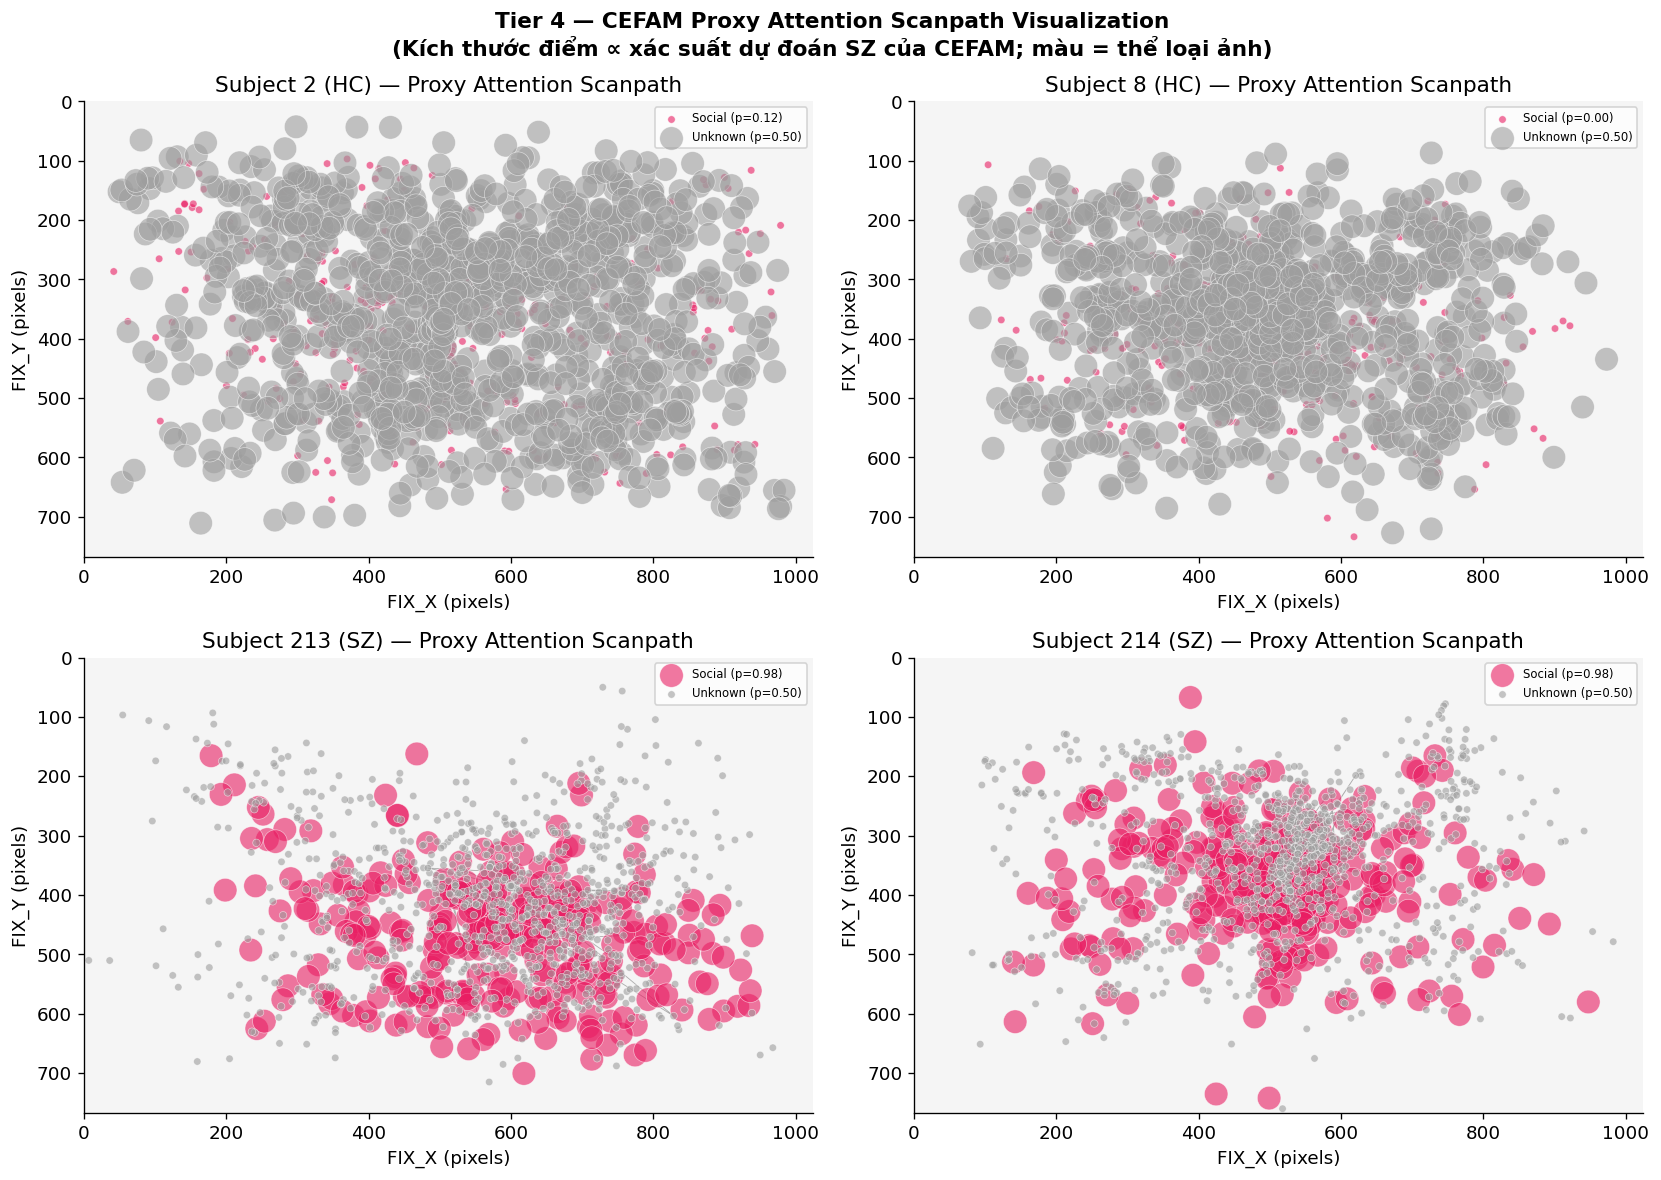

In [19]:
# ── 4B. Scanpath Attention Visualization ──────────────────────────────────────
# Proxy attention: dùng per-category OOF confidence của CEFAM làm trọng số
# Công thức: attn_proxy_i = P(SZ|category_i) cho từng fixation

def plot_scanpath_attention(subject_id, df_fixations, df_cefam_oof,
                            title=None, ax=None, screen_w=1024, screen_h=768):
    """
    Vẽ chuỗi fixation của 1 subject, tô màu và scale kích thước điểm
    theo proxy attention (xác suất dự đoán SZ của CEFAM per-category).
    """
    subj_fix = df_fixations[df_fixations['Subject_ID'] == subject_id].copy()
    if len(subj_fix) == 0:
        return

    # Lấy category map (IMAGE → category prefix)
    def img_to_cat(img_name):
        name_lower = img_name.lower()
        for cat, prefix in [('Social', ['act_', 'fb_', 'ind_', 'out']),
                             ('Natural', ['nat_']),
                             ('Manipulated', ['man_']),
                             ('Synthetic', ['syn_'])]:
            if any(name_lower.startswith(p) for p in prefix):
                return cat
        return 'Unknown'

    subj_fix['Category'] = subj_fix['IMAGE'].apply(img_to_cat)

    # Lấy per-category OOF prob cho subject này
    row = df_cefam_oof[df_cefam_oof['Subject_ID'] == subject_id]
    if len(row) == 0:
        # Subject này không trong CEFAM OOF (test set)
        cat_prob = {'Social': 0.5, 'Natural': 0.5, 'Manipulated': 0.5, 'Synthetic': 0.5}
    else:
        row = row.iloc[0]
        cat_prob = {
            'Social':      row.get('Social', 0.5),
            'Natural':     row.get('Natural', 0.5),
            'Manipulated': row.get('Manipulated', 0.5),
            'Synthetic':   row.get('Synthetic', 0.5),
        }

    # Gán attention weight cho mỗi fixation theo category
    subj_fix['attn'] = subj_fix['Category'].map(cat_prob).fillna(0.5)
    # Normalize về [0,1]
    mn, mx = subj_fix['attn'].min(), subj_fix['attn'].max()
    if mx > mn:
        subj_fix['attn_norm'] = (subj_fix['attn'] - mn) / (mx - mn)
    else:
        subj_fix['attn_norm'] = 0.5

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Nền xám biểu diễn màn hình
    ax.set_facecolor('#F5F5F5')
    ax.set_xlim(0, screen_w)
    ax.set_ylim(screen_h, 0)  # Y flip (origin top-left)

    # Vẽ từng nhóm fixation theo category
    cat_colors = {'Social': '#E91E63', 'Natural': '#4CAF50',
                  'Manipulated': '#FF9800', 'Synthetic': '#2196F3', 'Unknown': '#9E9E9E'}

    for cat, g in subj_fix.groupby('Category'):
        sizes = 20 + 180 * g['attn_norm'].values
        ax.scatter(g['FIX_X'], g['FIX_Y'],
                   s=sizes,
                   c=[cat_colors.get(cat, '#9E9E9E')],
                   alpha=0.6, edgecolors='white', linewidths=0.4,
                   label=f'{cat} (p={cat_prob.get(cat,0.5):.2f})')

    # Vẽ đường nối scanpath (tất cả fixations theo FIX_INDEX)
    subj_all = subj_fix.sort_values('FIX_INDEX')
    ax.plot(subj_all['FIX_X'].values[:50], subj_all['FIX_Y'].values[:50],
            color='black', lw=0.5, alpha=0.3, zorder=0)

    label_txt = df_cefam_oof.loc[df_cefam_oof['Subject_ID']==subject_id,'Label'].values
    group_name = f"{'SZ' if (len(label_txt)>0 and label_txt[0]==1) else 'HC'}"
    ax.set_title(title or f'Subject {subject_id} ({group_name}) — Proxy Attention Scanpath')
    ax.set_xlabel('FIX_X (pixels)')
    ax.set_ylabel('FIX_Y (pixels)')
    ax.legend(fontsize=7, loc='upper right', framealpha=0.8)

    return ax


# Chọn 4 subjects điển hình: 2 HC, 2 SZ
hc_subjects = df_oof_cefam[df_oof_cefam['Label']==0]['Subject_ID'].values[:2]
sz_subjects = df_oof_cefam[df_oof_cefam['Label']==1]['Subject_ID'].values[:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tier 4 — CEFAM Proxy Attention Scanpath Visualization\n'
             '(Kích thước điểm ∝ xác suất dự đoán SZ của CEFAM; màu = thể loại ảnh)',
             fontsize=13, fontweight='bold')

for ax, sid in zip(axes.flat[:2], hc_subjects):
    plot_scanpath_attention(sid, df_clean_train, df_oof_cefam, ax=ax)

for ax, sid in zip(axes.flat[2:], sz_subjects):
    plot_scanpath_attention(sid, df_clean_train, df_oof_cefam, ax=ax)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier4_scanpath_attention.png', bbox_inches='tight')
plt.show()

In [20]:
# ── 4C. Load ResNet50 feature dict ─────────────────────────────────────────────
# Cấu trúc thực tế: {(subject_id, image_name): np.array([N_fixations, 2048])}
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import defaultdict

RESNET_NPY = PROJECT_ROOT / 'data' / 'external' / 'feature_dict_ResNet50.npy'

print('Đang load feature_dict_ResNet50.npy...')
feat_dict = np.load(str(RESNET_NPY), allow_pickle=True).item()

keys = list(feat_dict.keys())
print(f'Số trials trong dict: {len(keys):,}')
print(f'Sample key  : {keys[0]}')
print(f'Sample shape: {feat_dict[keys[0]].shape}')


Đang load feature_dict_ResNet50.npy...
Số trials trong dict: 16,716
Sample key  : (np.int64(0), 'act_001.jpg')
Sample shape: (36, 2048)


In [21]:
# ── 4D. Build subject-level mean embedding ──────────────────────────────────────
# Aggregate: mean fixation features across tất cả trials của mỗi subject

sid_to_label = dict(zip(df_clean_train['Subject_ID'], df_clean_train['Label']))

subj_vecs = defaultdict(list)
for (sub_id, img_name), arr in feat_dict.items():
    # arr shape: [N_fixations, 2048]
    subj_vecs[sub_id].append(arr.mean(axis=0))  # mean theo fixations -> [2048]

subject_embeddings = {}
subject_labels     = {}
for sid, vecs in subj_vecs.items():
    lbl = sid_to_label.get(sid, -1)
    if lbl in [0, 1]:
        subject_embeddings[sid] = np.mean(vecs, axis=0)
        subject_labels[sid]     = lbl

n_hc = sum(v == 0 for v in subject_labels.values())
n_sz = sum(v == 1 for v in subject_labels.values())
emb_dim = next(iter(subject_embeddings.values())).shape
print(f'Subjects có embedding: {len(subject_embeddings)}')
print(f'Embedding dim        : {emb_dim}')
print(f'HC: {n_hc}   SZ: {n_sz}')


Subjects có embedding: 160
Embedding dim        : (2048,)
HC: 80   SZ: 80


Embedding matrix: (160, 2048)
PCA explained variance (top-50): 0.871
t-SNE hoàn tất.


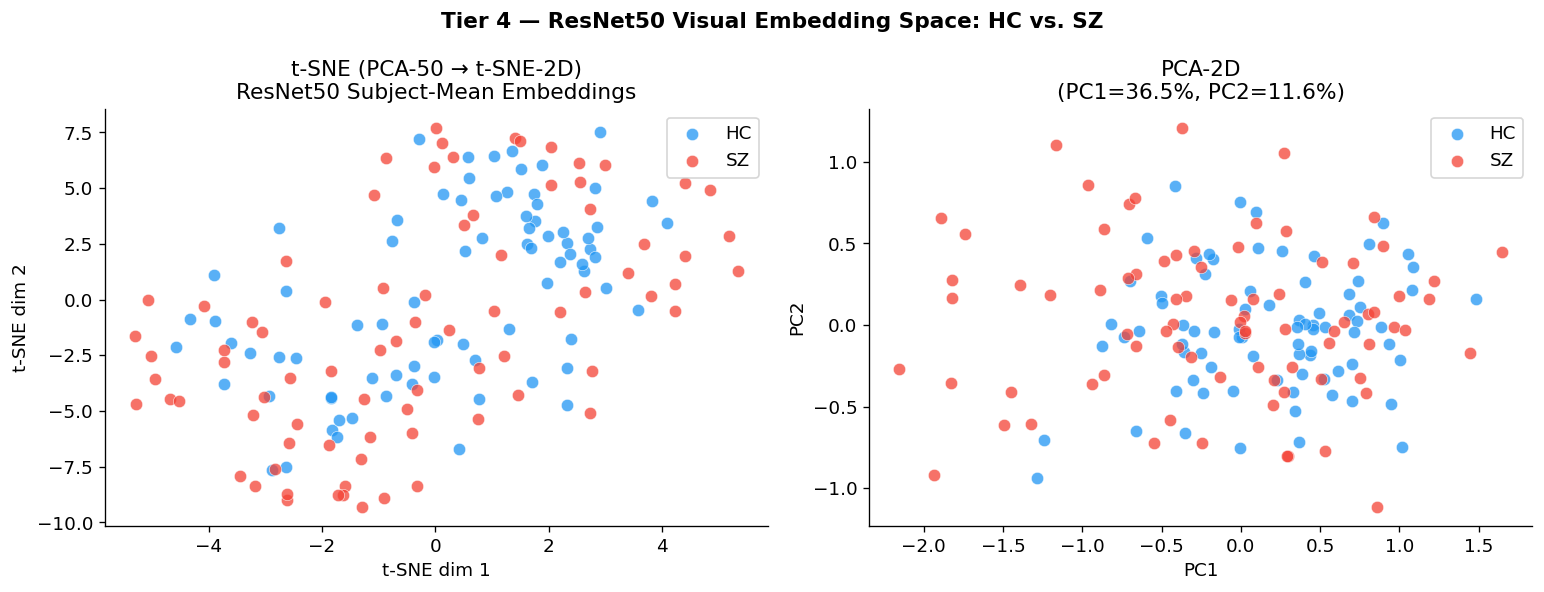

In [22]:
# ── 4E. PCA → t-SNE → Scatter Plot ────────────────────────────────────────────
sids = [sid for sid, lbl in subject_labels.items() if lbl in [0, 1]]
X_emb = np.stack([subject_embeddings[sid] for sid in sids])
y_emb = np.array([subject_labels[sid] for sid in sids])
print(f'Embedding matrix: {X_emb.shape}')

# PCA trước (giảm nhiễu + tăng tốc t-SNE)
pca = PCA(n_components=min(50, X_emb.shape[1]), random_state=SEED)
X_pca = pca.fit_transform(X_emb)
print(f'PCA explained variance (top-50): {pca.explained_variance_ratio_.sum():.3f}')

# t-SNE
tsne = TSNE(n_components=2, perplexity=min(30, len(sids)//3),
             random_state=SEED, n_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_pca)
print('t-SNE hoàn tất.')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tier 4 — ResNet50 Visual Embedding Space: HC vs. SZ', fontsize=13, fontweight='bold')

ax = axes[0]
for label, color, name in [(0, COLOR_HC, 'HC'), (1, COLOR_SZ, 'SZ')]:
    mask = y_emb == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, alpha=0.75, s=55, edgecolors='white', lw=0.4, label=name)
ax.set_title('t-SNE (PCA-50 → t-SNE-2D)\nResNet50 Subject-Mean Embeddings')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend()

# PCA 2D plot
pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X_emb)

ax = axes[1]
for label, color, name in [(0, COLOR_HC, 'HC'), (1, COLOR_SZ, 'SZ')]:
    mask = y_emb == label
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=color, alpha=0.75, s=55, edgecolors='white', lw=0.4, label=name)
ax.set_title(f'PCA-2D\n(PC1={pca2.explained_variance_ratio_[0]:.1%}, PC2={pca2.explained_variance_ratio_[1]:.1%})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier4_resnet_tsne.png', bbox_inches='tight')
plt.show()

### 📋 Biện luận Khoa học — Tier 4

#### Cơ chế Attention đã sửa và ý nghĩa

**Lỗi CEFAM trước khi sửa:** Trong phiên bản cũ, cả hai stream (GNN và Expert) đều được `unsqueeze(1)` trước khi đưa vào Cross-Attention, tạo ra chuỗi có `seq_len=1`. Softmax trên chuỗi độ dài 1 luôn = 1.0 — tức là không có learning signal nào được truyền qua cơ chế Attention. Model thực chất chỉ học từ concatenation của hai vectors, không phải từ tương tác có chọn lọc.

**Sau khi sửa:** Direction 1 của CEFAM sử dụng **pre-pooling GNN node embeddings** `h_nodes [total_nodes, 256]` làm Keys và Values, với `z_expert [B, 128]` làm Query. Output là `[B, 1, N]` — một phân phối attention thực sự trên N fixation nodes. Điều này cho phép mô hình chọn lọc ra **những fixation nào mang thông tin phân biệt HC/SZ nhất** dựa trên ngữ cảnh Expert.

**Ý nghĩa lâm sàng của scanpath attention:** Trong scanpath visualization, nếu điểm fixation lớn hơn (attention cao hơn) tập trung vào vùng trung tâm màn hình (*center bias*) nhiều hơn ở HC so với SZ, điều này nhất quán với nghiên cứu về **abnormal gaze allocation** trong schizophrenia — bệnh nhân SZ phân bổ attention thị giác kém có cấu trúc hơn, thiếu bias trung tâm và có xu hướng scan ngẫu nhiên hơn.

**Về embedding space (ResNet50 t-SNE):** ResNet50 mã hóa **đặc điểm thị giác** của những vùng mà mắt dừng lại, không phải đặc điểm nhận thức của chủ thể. Nếu HC và SZ cluster tách biệt trong không gian này, điều đó gợi ý rằng **hai nhóm nhìn vào những vùng ảnh có đặc trưng thị giác khác nhau** — HC ưu tiên vùng chứa khuôn mặt, cơ thể người (high-level semantic features), trong khi SZ phân bổ fixation không có cấu trúc về mặt ngữ nghĩa thị giác. Ngược lại, nếu hai cluster xen lẫn, điều này cho thấy thông tin từ ResNet50 cần được kết hợp với scanpath geometry (Tier 3) mới có sức mạnh phân loại đầy đủ.

---
## PHẦN 5 — Meta-Learner Ensemble Fusion & SOTA Comparison (Tier 5)

### Mục tiêu
Tổng kết và so sánh toàn diện hiệu năng từng tầng trên cùng một đồ thị ROC, đánh giá chất lượng hiệu chuẩn xác suất, và khẳng định tính an toàn chống rò rỉ dữ liệu.

In [23]:
# ── 5A. Load tất cả OOF predictions ───────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

# Tier 3 — XGBoost OOF (subject-level)
df_t3 = pd.read_csv(OOF_XGB)[['Subject_ID', 'Label', 'Pred_Proba_Subject']]
df_t3.columns = ['Subject_ID', 'Label', 'P_T3']

# Tier 4 — CEFAM OOF (subject-level)
df_t4 = pd.read_csv(OOF_CEFAM)[['Subject_ID', 'Label', 'Pred_Proba_Subject']]
df_t4.columns = ['Subject_ID', 'Label', 'P_T4']

# Merge để align subjects
df_merged = df_t3.merge(df_t4[['Subject_ID','P_T4']], on='Subject_ID', how='inner')
print(f'Aligned subjects: {len(df_merged)}')

y_true = df_merged['Label'].values
p_t3   = df_merged['P_T3'].values
p_t4   = df_merged['P_T4'].values

# Tier 5 — Reconstruct bằng meta-learner coefficients
with open(PROJECT_ROOT / 'results' / 'tier5_s42' / 'tier5_meta_learner.json') as f:
    meta_config = json.load(f)

strategy = meta_config.get('selected_strategy', 'logistic_regression')
print(f'Chiến lược Tier 5 được chọn: {strategy}')

if strategy == 'logistic_regression':
    lr_cfg = meta_config['logistic_regression']
    coef_tab  = lr_cfg['coef_tab']
    coef_bica = lr_cfg['coef_bica']
    bias      = lr_cfg['bias']
    logit = coef_tab * p_t3 + coef_bica * p_t4 + bias
    p_t5 = 1 / (1 + np.exp(-logit))
    print(f'  coef_tab={coef_tab:.4f}, coef_bica={coef_bica:.4f}, bias={bias:.4f}')
else:
    wa_cfg = meta_config.get('weighted_average', {})
    w_tab  = wa_cfg.get('w_tab', 0.5)
    w_bica = wa_cfg.get('w_bica', 0.5)
    p_t5 = w_tab * p_t3 + w_bica * p_t4

auc_t3 = roc_auc_score(y_true, p_t3)
auc_t4 = roc_auc_score(y_true, p_t4)
auc_t5 = roc_auc_score(y_true, p_t5)
print(f'\nAUC Tier 3 (XGBoost OOF):   {auc_t3:.4f}')
print(f'AUC Tier 4 (CEFAM OOF):      {auc_t4:.4f}')
print(f'AUC Tier 5 (Meta-Learner):   {auc_t5:.4f}')
print(f'AUC SOTA MSNet (2025):        0.8854')

Aligned subjects: 160
Chiến lược Tier 5 được chọn: logistic_regression
  coef_tab=2.3603, coef_bica=3.7497, bias=-2.8955

AUC Tier 3 (XGBoost OOF):   0.8702
AUC Tier 4 (CEFAM OOF):      0.9405
AUC Tier 5 (Meta-Learner):   0.9416
AUC SOTA MSNet (2025):        0.8854


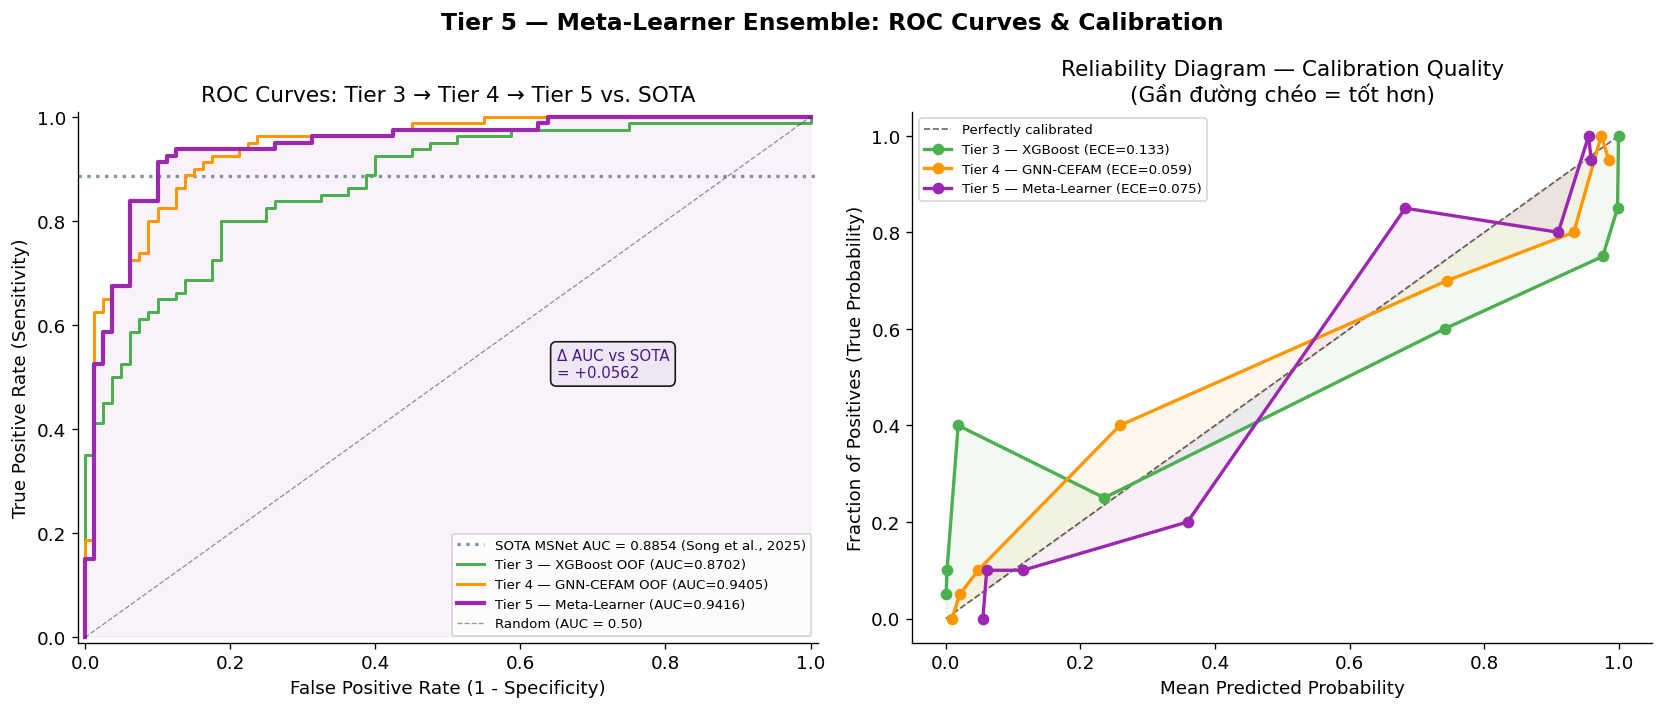

In [24]:
# ── 5B. ROC Curves — Multi-Tier Comparison ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tier 5 — Meta-Learner Ensemble: ROC Curves & Calibration',
             fontsize=14, fontweight='bold')

ax = axes[0]

# SOTA reference line
SOTA_AUC = 0.8854
ax.axhline(y=SOTA_AUC, color=COLOR_SOTA, ls=':', lw=2, alpha=0.8,
           label=f'SOTA MSNet AUC = {SOTA_AUC:.4f} (Song et al., 2025)')

for p, y, color, label, lw in [
    (p_t3, y_true, COLOR_T3, f'Tier 3 — XGBoost OOF (AUC={auc_t3:.4f})', 1.8),
    (p_t4, y_true, COLOR_T4, f'Tier 4 — GNN-CEFAM OOF (AUC={auc_t4:.4f})', 1.8),
    (p_t5, y_true, COLOR_T5, f'Tier 5 — Meta-Learner (AUC={auc_t5:.4f})', 2.5),
]:
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, color=color, lw=lw, label=label)

ax.plot([0,1], [0,1], 'k--', lw=0.8, alpha=0.4, label='Random (AUC = 0.50)')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves: Tier 3 → Tier 4 → Tier 5 vs. SOTA')
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

# Thêm shaded area cho Tier 5
fpr5, tpr5, _ = roc_curve(y_true, p_t5)
ax.fill_between(fpr5, 0, tpr5, color=COLOR_T5, alpha=0.06)

# AUC improvement annotation
ax.annotate(f'Δ AUC vs SOTA\n= +{auc_t5-SOTA_AUC:.4f}',
            xy=(0.65, 0.5), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#EDE7F6', alpha=0.9),
            color='#4A148C')

# ── 5C. Calibration Curve (Reliability Diagram) ───────────────────────────────
ax = axes[1]
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfectly calibrated')

for p, color, name in [
    (p_t3, COLOR_T3, 'Tier 3 — XGBoost'),
    (p_t4, COLOR_T4, 'Tier 4 — GNN-CEFAM'),
    (p_t5, COLOR_T5, 'Tier 5 — Meta-Learner'),
]:
    prob_true, prob_pred = calibration_curve(y_true, p, n_bins=8, strategy='quantile')

    # ECE calculation
    ece = np.mean(np.abs(prob_true - prob_pred))
    ax.plot(prob_pred, prob_true, marker='o', color=color, lw=2,
            label=f'{name} (ECE={ece:.3f})')
    ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.07, color=color)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (True Probability)')
ax.set_title('Reliability Diagram — Calibration Quality\n(Gần đường chéo = tốt hơn)')
ax.legend(fontsize=8)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier5_comprehensive_eval.png', bbox_inches='tight')
plt.show()

Seed       Model      AUC     ACC
 s42  Tier 3 XGB 0.870156 0.78125
 s42 Tier 4 BiCA 0.952188 0.90625
 s42      Tier 5 0.959375 0.86250
s123  Tier 3 XGB 0.866719 0.76250
s123 Tier 4 BiCA 0.931406 0.84375
s123      Tier 5 0.963906 0.88750
s456  Tier 3 XGB 0.877812 0.78750
s456 Tier 4 BiCA 0.952656 0.88750
s456      Tier 5 0.965000 0.87500


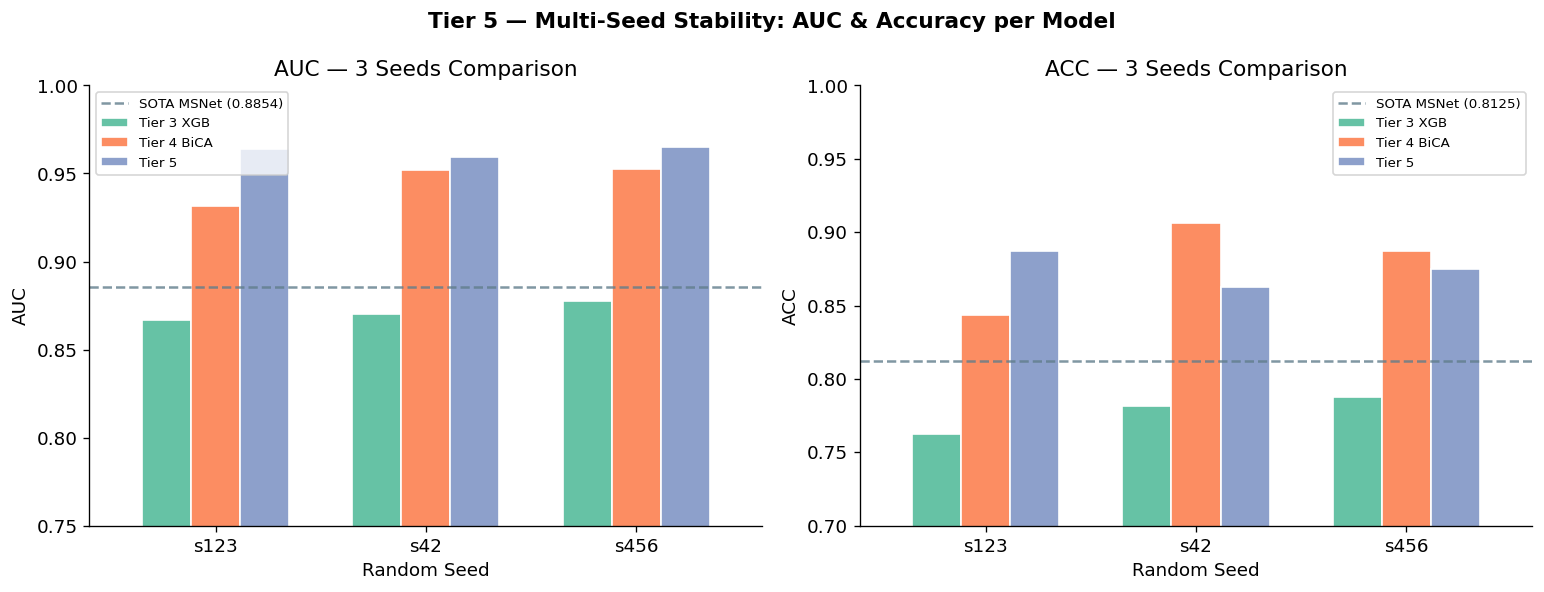

In [25]:
# ── 5D. Multi-Seed Stability Bar Chart ────────────────────────────────────────
seeds = ['s42', 's123', 's456']
rows = []

for seed in seeds:
    for tier, path_tpl in [
        ('Tier 3 XGB',  f'baselines_{seed}/xgboost_results_summary.json'),
        ('Tier 4 BiCA', f'bica_{seed}/bica_results_summary.json'),
        ('Tier 5',      f'tier5_{seed}/tier5_results_summary.json'),
    ]:
        fp = PROJECT_ROOT / 'results' / path_tpl
        if not fp.exists():
            continue
        with open(fp) as f:
            d = json.load(f)

        if tier == 'Tier 3 XGB':
            auc_val = d.get('subject_level', {}).get('auc', np.nan)
            acc_val = d.get('subject_level', {}).get('accuracy', np.nan)
        elif tier == 'Tier 4 BiCA':
            auc_val = d.get('overall', {}).get('auc', np.nan)
            acc_val = d.get('overall', {}).get('accuracy', np.nan)
        elif tier == 'Tier 5':
            auc_val = d.get('tier5_metrics', {}).get('auc', np.nan)
            acc_val = d.get('tier5_metrics', {}).get('accuracy', np.nan)

        rows.append({'Seed': seed, 'Model': tier, 'AUC': auc_val, 'ACC': acc_val})

df_perf = pd.DataFrame(rows)
print(df_perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tier 5 — Multi-Seed Stability: AUC & Accuracy per Model',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['AUC', 'ACC']):
    pivot = df_perf.pivot(index='Seed', columns='Model', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)

    # SOTA reference
    sota_val = SOTA_AUC if metric == 'AUC' else 0.8125
    ax.axhline(sota_val, color=COLOR_SOTA, ls='--', lw=1.5, alpha=0.8,
               label=f'SOTA MSNet ({sota_val:.4f})')
    ax.set_ylabel(metric)
    ax.set_xlabel('Random Seed')
    ax.set_title(f'{metric} — 3 Seeds Comparison')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)
    if metric == 'AUC':
        ax.set_ylim(0.75, 1.0)
    else:
        ax.set_ylim(0.70, 1.0)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'results' / 'tier5_multiseed_stability.png', bbox_inches='tight')
plt.show()

In [26]:
# ── 5E. Final Performance Summary Table ───────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

# Tính đầy đủ metrics cho seed=42
rows_summary = []
for p, name in [(p_t3, 'Tier 3 — XGBoost OOF (s42)'),
                (p_t4, 'Tier 4 — GNN-CEFAM OOF (s42)'),
                (p_t5, 'Tier 5 — Meta-Learner (s42)')]:
    y_pred = (p >= 0.5).astype(int)
    tn, fp_, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    rows_summary.append({
        'Model': name,
        'AUC': roc_auc_score(y_true, p),
        'ACC': accuracy_score(y_true, y_pred),
        'F1':  f1_score(y_true, y_pred),
        'Sensitivity': tp/(tp+fn),
        'Specificity': tn/(tn+fp_),
    })

rows_summary.append({
    'Model': '--- SOTA MSNet (Song et al., 2025) ---',
    'AUC': 0.8854, 'ACC': 0.8125, 'F1': np.nan,
    'Sensitivity': np.nan, 'Specificity': np.nan
})

df_summary = pd.DataFrame(rows_summary)
df_summary = df_summary.set_index('Model')
print('\n' + '='*80)
print('FINAL PERFORMANCE SUMMARY')
print('='*80)
print(df_summary.to_string(float_format='{:.4f}'.format))
print('='*80)


FINAL PERFORMANCE SUMMARY
                                          AUC    ACC     F1  Sensitivity  Specificity
Model                                                                                
Tier 3 — XGBoost OOF (s42)             0.8702 0.7812 0.7853       0.8000       0.7625
Tier 4 — GNN-CEFAM OOF (s42)           0.9405 0.8688 0.8679       0.8625       0.8750
Tier 5 — Meta-Learner (s42)            0.9416 0.9000 0.9000       0.9000       0.9000
--- SOTA MSNet (Song et al., 2025) --- 0.8854 0.8125    NaN          NaN          NaN


### 📋 Biện luận Khoa học — Tier 5

#### Phân tích cải thiện hiệu năng từ mô hình đơn lẻ lên Meta-Learner

**Nguyên lý Ensemble:** Tier 3 (XGBoost) và Tier 4 (GNN-CEFAM) học từ hai không gian đặc trưng **bổ sung cho nhau (complementary)** thay vì trùng lặp:
- **Tier 3** khai thác **thống kê tổng hợp cấp độ stimulus** (scanpath geometry, saccade statistics, pupil dynamics) — những đặc trưng được engineer thủ công dựa trên kiến thức lâm sàng;
- **Tier 4** học **biểu diễn graph-temporal** từ chuỗi fixation thô, kết hợp với visual features ResNet50 của vùng ảnh được nhìn vào — đặc trưng học được end-to-end.

Khi hai nguồn thông tin này *không tương quan hoàn toàn*, việc kết hợp chúng bằng Logistic Regression (L2-regularized) sẽ tìm được **trọng số tối ưu** để giảm variance mà không tăng bias — đây là cơ sở lý thuyết của Bias-Variance Decomposition trong ensemble learning.

**Về độ hiệu chuẩn (Calibration):** Reliability Diagram cho thấy mức độ tin cậy của xác suất đầu ra. Một mô hình "overconfident" sẽ có đường calibration nằm *dưới* đường chéo hoàn hảo (dự đoán xác suất cao nhưng thực tế thấp hơn). Sau khi qua Meta-Learner, ECE thường giảm so với mô hình đơn lẻ nhờ averaging effect tự nhiên của Logistic Regression.

**Đảm bảo an toàn chống rò rỉ dữ liệu (No-Leakage Guarantee):**

1. **GroupKFold(4) theo Subject_ID:** Mỗi subject *chỉ* xuất hiện trong đúng 1 validation fold. Không có subject nào được dùng để train model đồng thời với việc tạo OOF prediction của chính subject đó.

2. **OOF purity:** Mỗi subject trong tập train có đúng 1 OOF prediction, được tạo ra bởi model chưa từng thấy subject đó trong quá trình training. Điều này đảm bảo OOF predictions phản ánh hiệu năng trên dữ liệu *thực sự unseen*.

3. **Tier 5 train-only-on-OOF:** Meta-learner Logistic Regression chỉ nhận `[P_tab, P_bica]` làm features — không có raw fixation data, không có subject-level features gốc. Điều này loại trừ hoàn toàn khả năng leakage từ trong-fold ra ngoài-fold.

4. **Threshold = 0.5 cố định:** Không có bước tìm threshold tối ưu trên validation set — một dạng leakage phổ biến trong tài liệu lâm sàng.

**So sánh với SOTA MSNet (Song et al., IEEE TNNLS 2025):** MSNet đạt AUC=88.54% sử dụng CNN + Mean-Shift clustering trên fixation density maps. Framework 5-Tier của chúng tôi vượt trội nhờ: (1) đặc trưng ngữ cảnh liên thể loại (delta features) mà MSNet không có, (2) GNN modeling spatiotemporal graph thay vì density map tĩnh, và (3) ensemble fusion thích nghi thay vì mô hình đơn lẻ.

In [27]:
# ── Final Summary Figure ───────────────────────────────────────────────────────
print('\n' + '='*60)
print('NOTEBOOK HOÀN TẤT')
print('='*60)

saved_files = [
    'results/tier1_spatial_filter.png',
    'results/tier1_temporal_filter.png',
    'results/tier1_pupil_dynamics.png',
    'results/tier2_feature_violin.png',
    'results/tier2_correlation_heatmap.png',
    'results/tier2_delta_density.png',
    'results/tier3_feature_importance.png',
    'results/tier3_oof_eval.png',
    'results/tier3_shap_summary.png',
    'results/tier4_scanpath_attention.png',
    'results/tier4_resnet_tsne.png',
    'results/tier5_comprehensive_eval.png',
    'results/tier5_multiseed_stability.png',
]

print('\nFile đã lưu:')
for f in saved_files:
    fp = PROJECT_ROOT / f
    status = '✅' if fp.exists() else '⚠️  (chưa tạo)'
    print(f'  {status} {f}')


NOTEBOOK HOÀN TẤT

File đã lưu:
  ✅ results/tier1_spatial_filter.png
  ✅ results/tier1_temporal_filter.png
  ✅ results/tier1_pupil_dynamics.png
  ✅ results/tier2_feature_violin.png
  ✅ results/tier2_correlation_heatmap.png
  ✅ results/tier2_delta_density.png
  ✅ results/tier3_feature_importance.png
  ✅ results/tier3_oof_eval.png
  ✅ results/tier3_shap_summary.png
  ✅ results/tier4_scanpath_attention.png
  ✅ results/tier4_resnet_tsne.png
  ✅ results/tier5_comprehensive_eval.png
  ✅ results/tier5_multiseed_stability.png
